In [2]:
import os
import sys
import gc
import base64
import joblib 
import itertools
from io import BytesIO
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from functools import reduce

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import f_classif, mutual_info_classif
from scipy.stats import kruskal
import tensorflow as tf
from cycler import cycler
from matplotlib.colors import to_hex

import pickle

import config
EXCLUDED_FEATURES = config.EXCLUDED_FEATURES.copy()
FEATURE_GROUPS = config.FEATURE_GROUPS.copy()
curve_split = config.CURVE_SPLIT.copy()
metrics = config.IMPORTANCE_METRICS.copy()


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



In [3]:
# ['ori_curves',
#   'ori_curves_avg',
#   'original_fitted_full',
#   'original_fitted_stretched',
#   'cleaned_std_fitted_full',
#   'cleaned_std_fitted_stretched',
#   'cleaned_lowest_fitted_full',
#   'cleaned_lowest_fitted_stretched',
#   'avg_lowest_fitted_full',
#   'avg_lowest_fitted_stretched',
#   'avg_cleaned_std_lowest_fitted_full',
#   'avg_cleaned_std_lowest_fitted_stretched',
#   'avg_cleaned_lowest_lowest_fitted_full',
#   'avg_cleaned_lowest_lowest_fitted_stretched']

# choose kinetics[:8]

## Data structure

In [5]:
exp_root = config.DEFAULT_EXP_FOLDER

feature_analysis_path = os.path.join(exp_root, 'feature_analysis.pkl')

with open(feature_analysis_path, 'rb') as f:
    feature_analysis_data = pickle.load(f)

dataset_metadata = feature_analysis_data["dataset_metadata"]
curve_metadata = feature_analysis_data["curve_metadata"]
dataset = feature_analysis_data["dataset"]


In [6]:
print(f"curve_metadata")
for k, v in curve_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset_metadata")
for k, v in dataset_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset")
for k, v in dataset.items():
    print(f"{k}: {len(v)} x {len(v[0])}")


curve_metadata
name: 8

dataset_metadata
name: 10
Y_well: 10
timestamps: 10

dataset
kinetic_features: 10 x 8
dataset_curves: 10 x 8
feature_scores: 10 x 8
feature_ranks: 10 x 8


In [7]:
curve_metadata["name"]

['ori_curves',
 'ori_curves_avg',
 'original_fitted_full',
 'original_fitted_stretched',
 'cleaned_std_fitted_full',
 'cleaned_std_fitted_stretched',
 'cleaned_lowest_fitted_full',
 'cleaned_lowest_fitted_stretched']

In [8]:
dataset["kinetic_features"][0][0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'amplitude', 'dy_xms',
       'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2', 'threshold_distance',
       'first_half_distance', 'second_half_distance',
       'distance_asymmetry_index', 'peak_shifting_distance', 'A1', 'A2',
       'area_asymmetry_index', 'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0',
       'F0', 'pixel_row_idx', 'pixel_col_idx', 'temp_group_idx',
       'num_active_pixels_in_temp_group', 'well_temp_lin2d_mean',
       'well_2d_temp_npr_mean', 'send_5', 'send_abs_5', 'send_10',
       'send_abs_10', 'send_15', 'send_abs_15', 'send_20', 'send_abs_20',
       'send_25', 'send_abs_25', 'FFI', 'F_range', 'cnn_ae_pw_ds1_label_elbow',
       'cnn_ae_pw_ds1_label_90', 'cnn_ae_pw_ds1_label_95',
       'cnn_ae_glb_ds1_label_elbow',

## Curve Importance Summary

In [9]:
curve_metadata["feature_scores"] = {m: [] for m in metrics}
curve_metadata["feature_ranks"] = {m: [] for m in metrics}

for j, curve_name in enumerate(curve_metadata['name']):
    # Temporary storage for merging across datasets
    curve_scores_dict = {m: [] for m in metrics}
    curve_ranks_dict = {m: [] for m in metrics}
    
    for i, dataset_name in enumerate(dataset_metadata['name']):
        # Load the new data structures
        scores_df = dataset["feature_scores"][i][j].copy()
        ranks_df = dataset["feature_ranks"][i][j].copy()
        
        # Filter excluded features
        scores_df = scores_df[~scores_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        ranks_df = ranks_df[~ranks_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        for m in metrics:
            # Extract just the feature and specific metric, rename the metric column to the dataset name
            s_df = scores_df[['feature', m]].rename(columns={m: dataset_name})
            r_df = ranks_df[['feature', m]].rename(columns={m: dataset_name})
            
            curve_scores_dict[m].append(s_df)
            curve_ranks_dict[m].append(r_df)
            
    # Merge and store the results for each metric
    for m in metrics:
        merged_scores = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_scores_dict[m])
        merged_ranks = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_ranks_dict[m])
        
        curve_metadata["feature_scores"][m].append(merged_scores)
        curve_metadata["feature_ranks"][m].append(merged_ranks)

## Dataset Importance Summary

In [10]:
dataset_metadata["feature_scores"] = {m: [] for m in metrics}
dataset_metadata["feature_ranks"] = {m: [] for m in metrics}

for i, dataset_name in enumerate(dataset_metadata['name']):
    dataset_scores_dict = {m: [] for m in metrics}
    dataset_ranks_dict = {m: [] for m in metrics}
    
    for j, curve_name in enumerate(curve_metadata['name']):
        scores_df = dataset["feature_scores"][i][j].copy()
        ranks_df = dataset["feature_ranks"][i][j].copy()
        
        scores_df = scores_df[~scores_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        ranks_df = ranks_df[~ranks_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        for m in metrics:
            s_df = scores_df[['feature', m]].rename(columns={m: curve_name})
            r_df = ranks_df[['feature', m]].rename(columns={m: curve_name})
            
            dataset_scores_dict[m].append(s_df)
            dataset_ranks_dict[m].append(r_df)
            
    for m in metrics:
        merged_scores = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_scores_dict[m])
        merged_ranks = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_ranks_dict[m])
        
        dataset_metadata["feature_scores"][m].append(merged_scores)
        dataset_metadata["feature_ranks"][m].append(merged_ranks)

## All Importance Summary

In [11]:
summary = {}
summary['curve_feature_median_rank'] = {}

for m in metrics:
    curve_rank_summary = []
    
    # Pair the curve names with their respective merged rank dataframe for this specific metric
    for curve_name, rank_df in zip(curve_metadata['name'], curve_metadata["feature_ranks"][m]):
        rank_df_temp = rank_df.copy()
        rank_cols = [col for col in rank_df_temp.columns if col != 'feature']
        
        # Calculate the median rank across all datasets for this curve
        rank_df_temp['median_rank'] = rank_df_temp[rank_cols].median(axis=1)

        # Extract only the feature and its median rank, renaming the column to the curve name
        df = rank_df_temp[['feature', 'median_rank']].rename(columns={'median_rank': curve_name})
        curve_rank_summary.append(df)

    # Merge all 8 curves together to create a master comparison matrix for this metric
    merged_summary = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_rank_summary)
    
    # Store it in the summary dictionary under the metric name
    summary['curve_feature_median_rank'][m] = merged_summary

## Rank Viz

In [12]:
def plot_feature_heatmap_on_ax(df, ax, title="", calculate_summary=False, n_rank=None, show_cbar=True):
    ranked_df = df.copy()
    
    if calculate_summary:
        rank_cols = [col for col in ranked_df.columns if col != 'feature']
        ranked_df['median_rank'] = ranked_df[rank_cols].median(axis=1)
        ranked_df['mean_rank'] = ranked_df[rank_cols].mean(axis=1)
        ranked_df = ranked_df.sort_values('median_rank').reset_index(drop=True)
        if isinstance(n_rank, int):
            ranked_df = ranked_df.iloc[:n_rank]
    
    heatmap_df = ranked_df.set_index('feature')

    sns.heatmap(
        heatmap_df, 
        cmap="Greens_r", 
        annot=True,          
        fmt=".1f",           
        linewidths=0.5,      
        cbar=show_cbar,
        cbar_kws={'label': 'Median Rank (Lower = Better)'} if show_cbar else None,
        ax=ax
    )

    ax.set_title(title, fontweight='bold', pad=15)
    ax.set_ylabel('Features', fontweight='bold', labelpad=5)
    
    # Rotate and align x-axis labels safely for subplots
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='y', rotation=0)

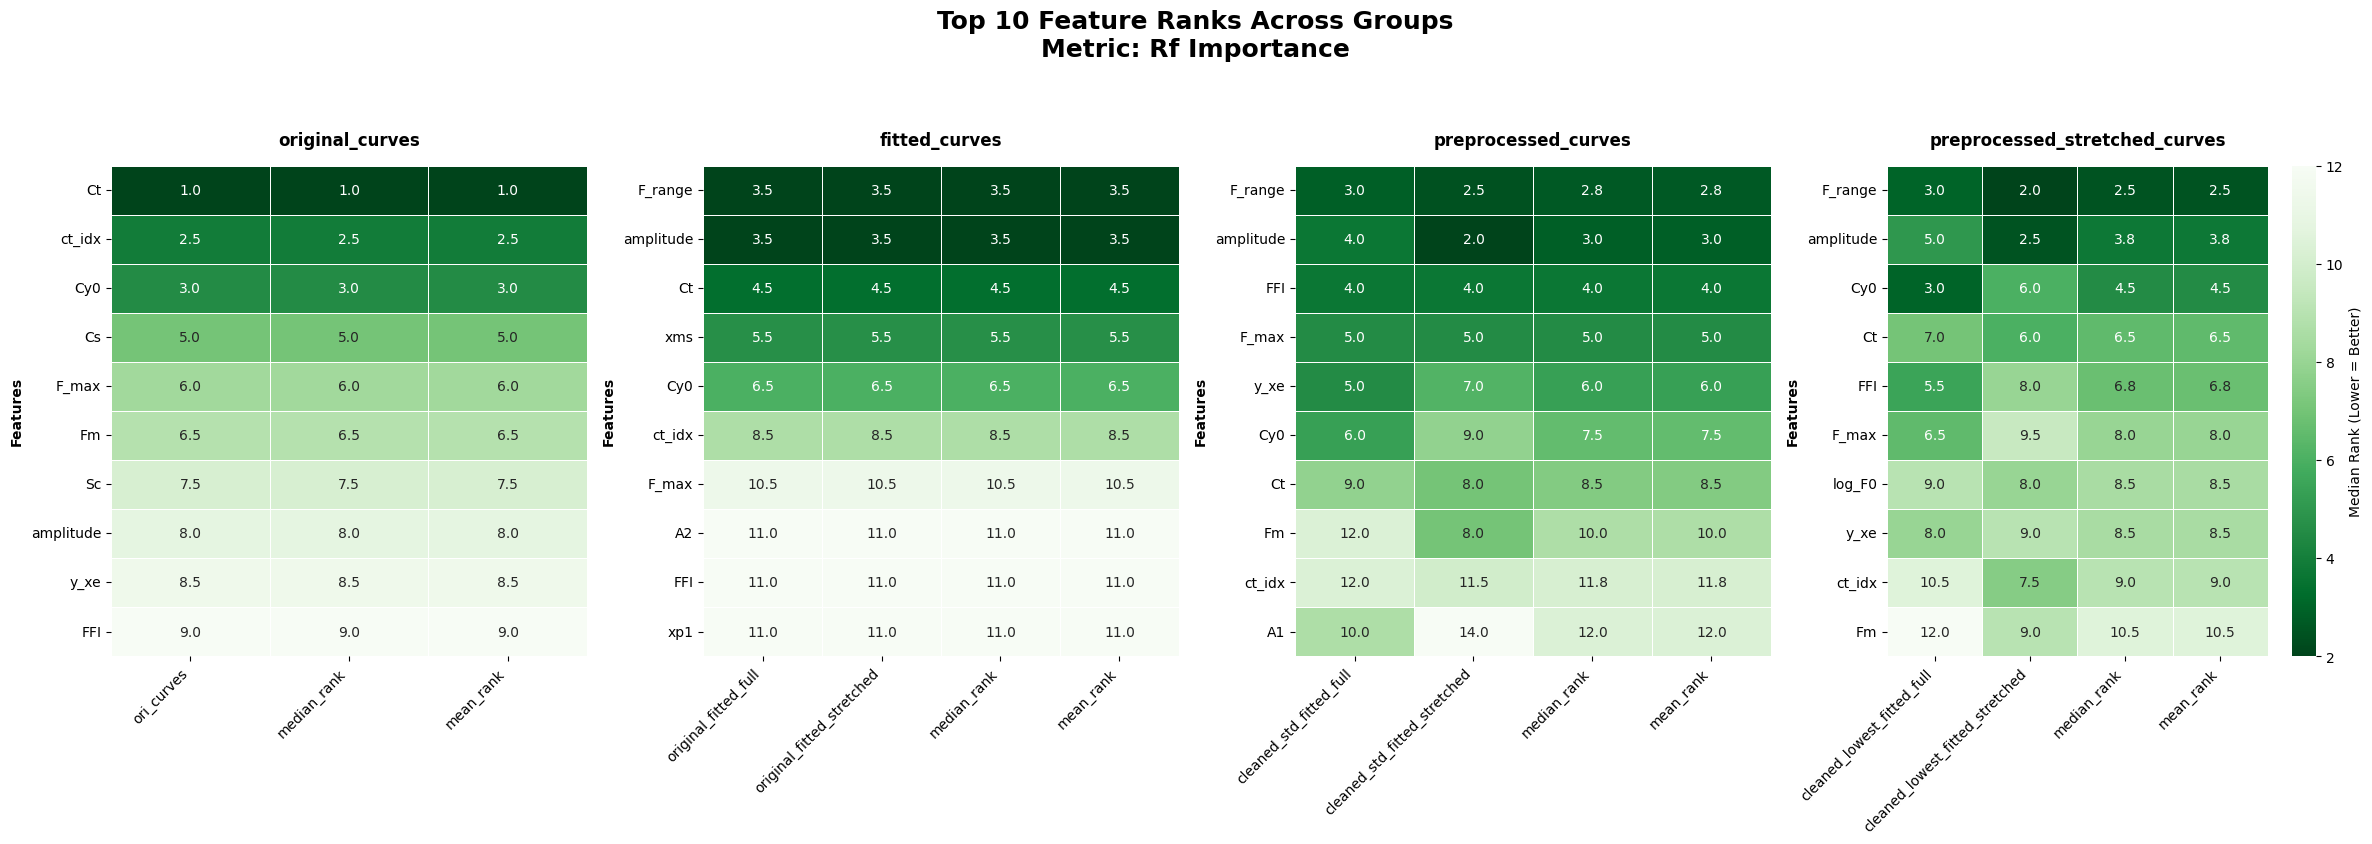

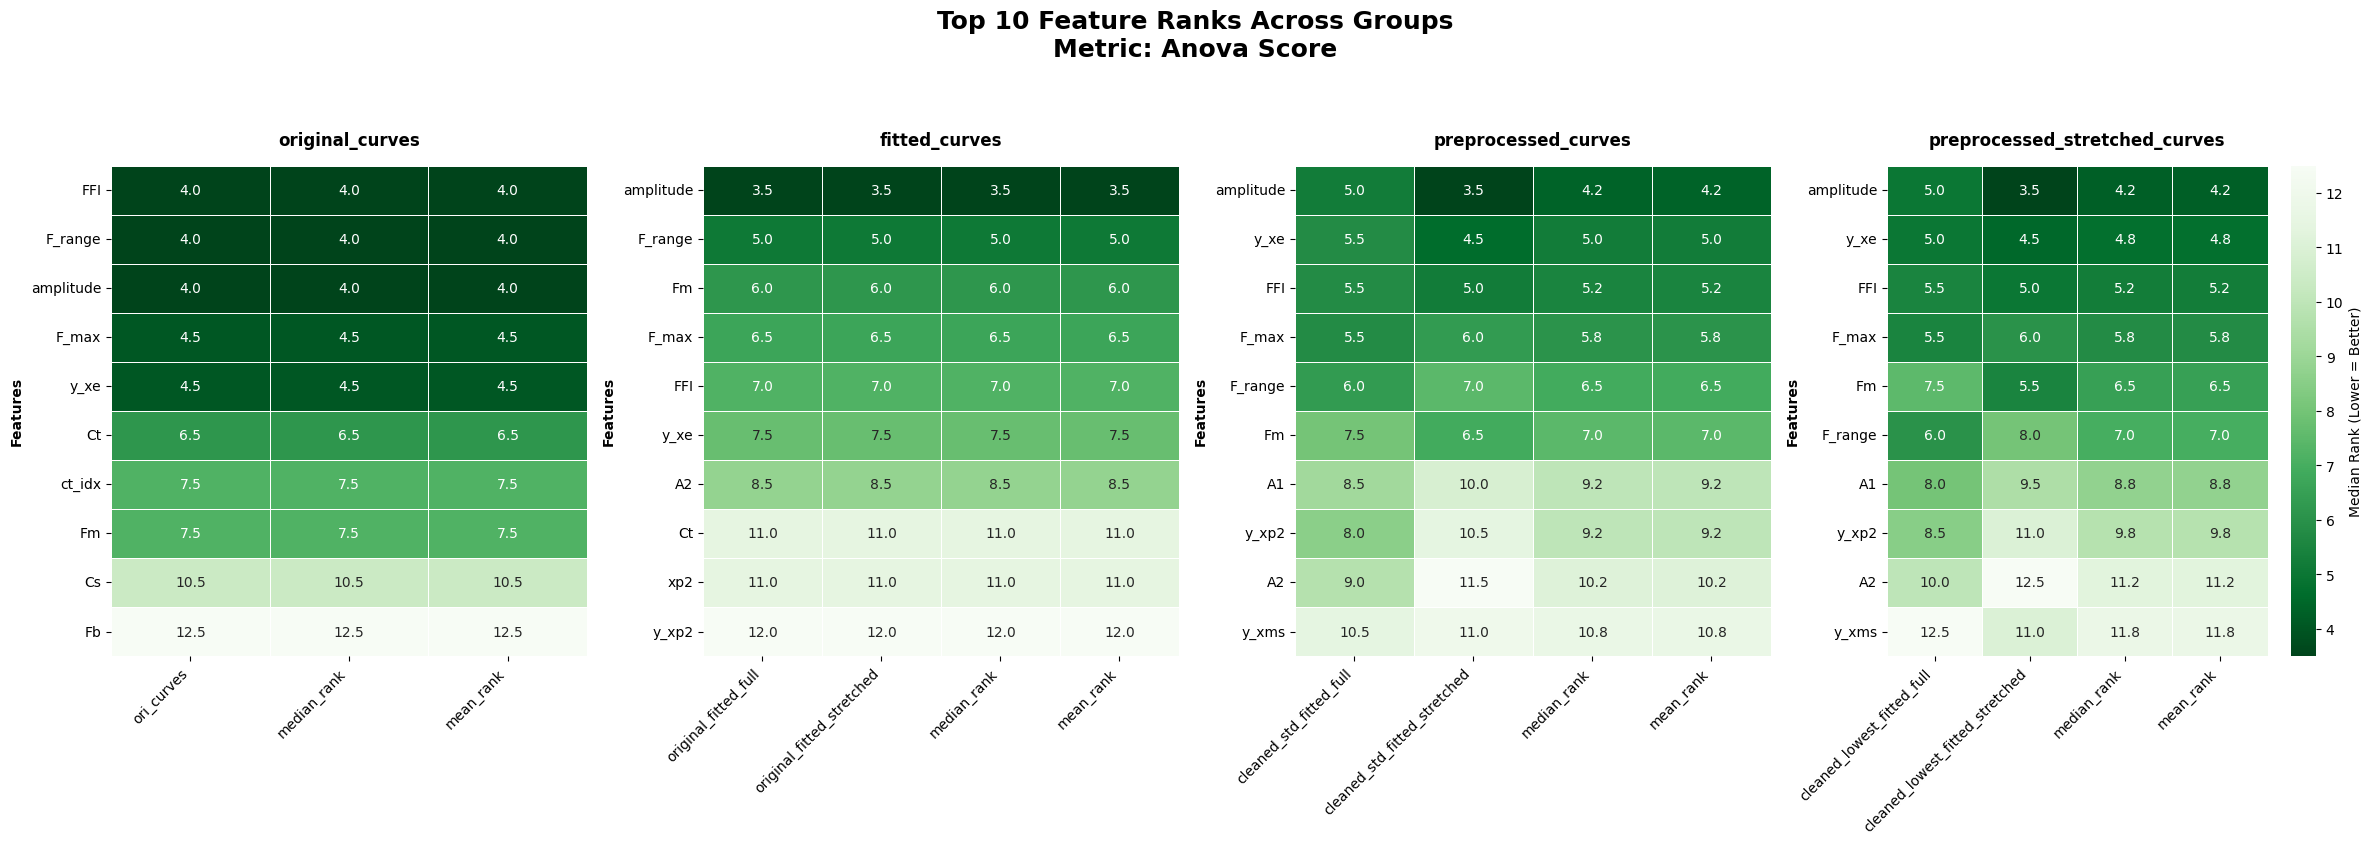

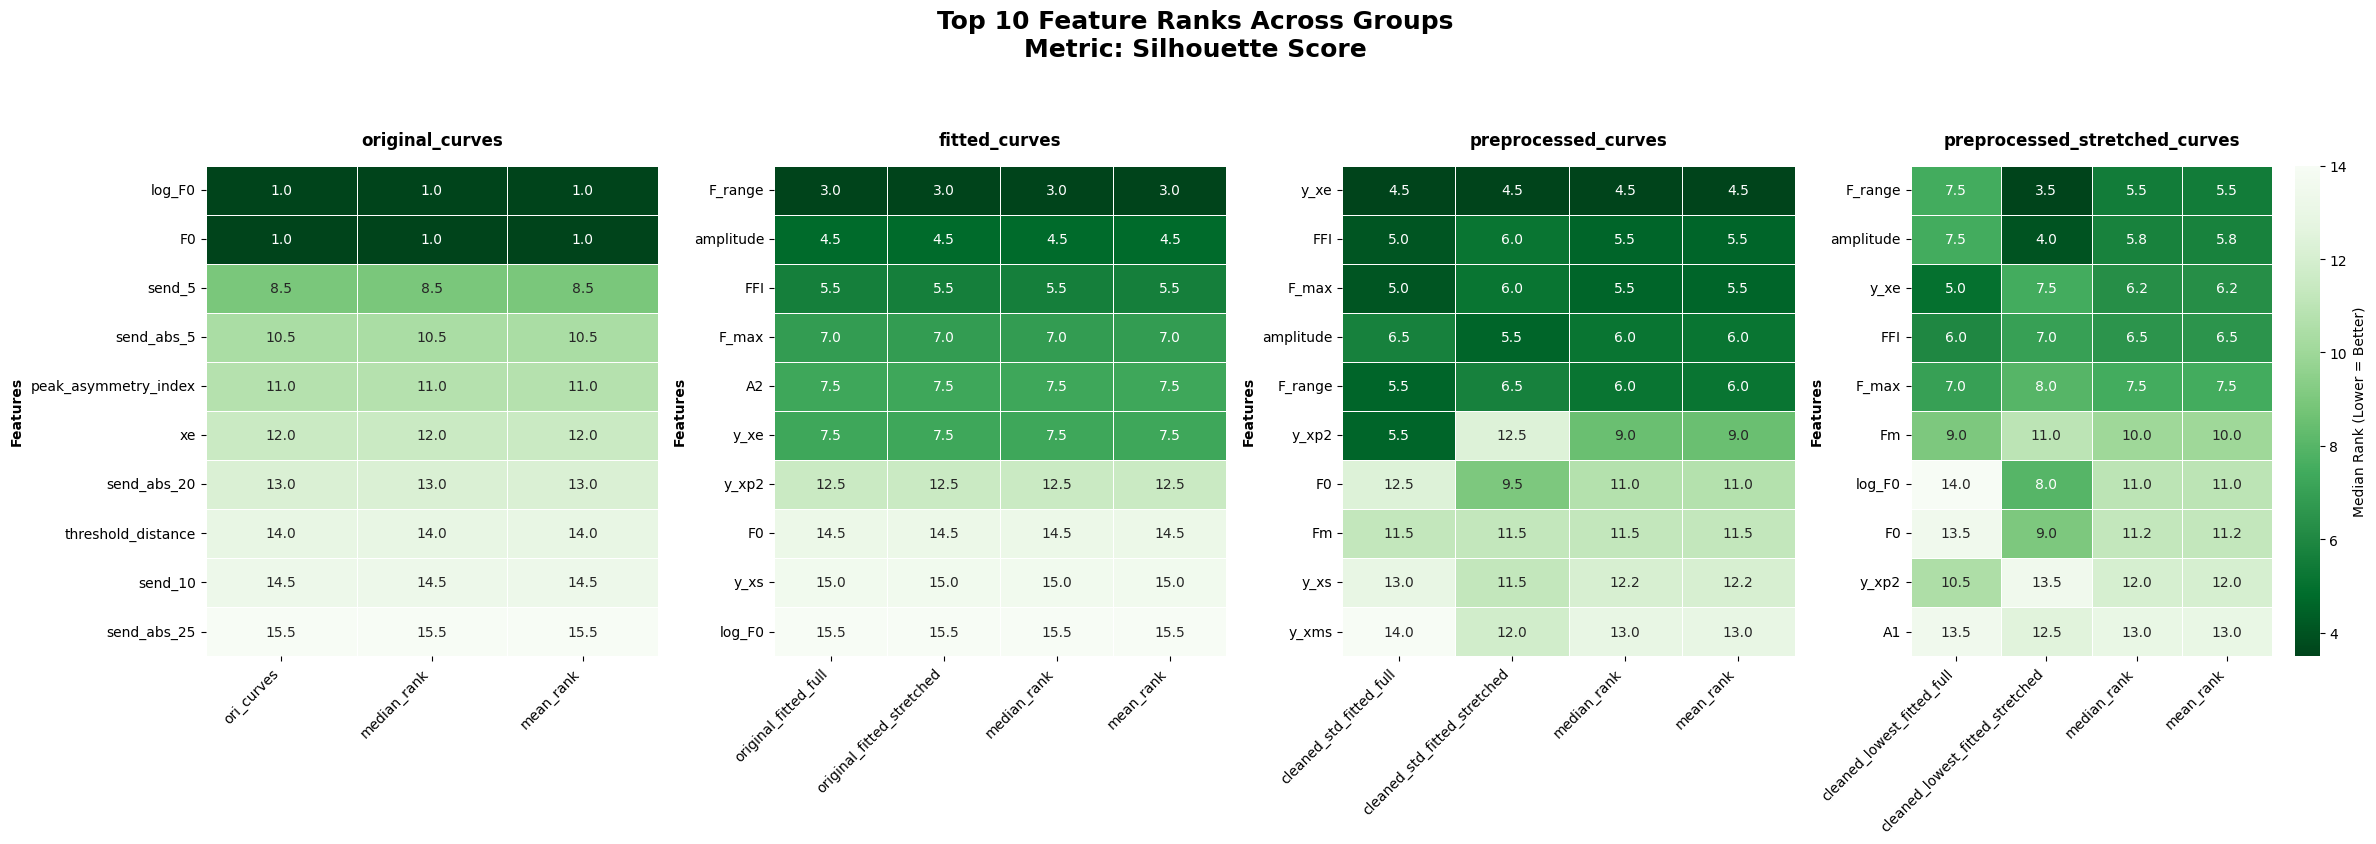

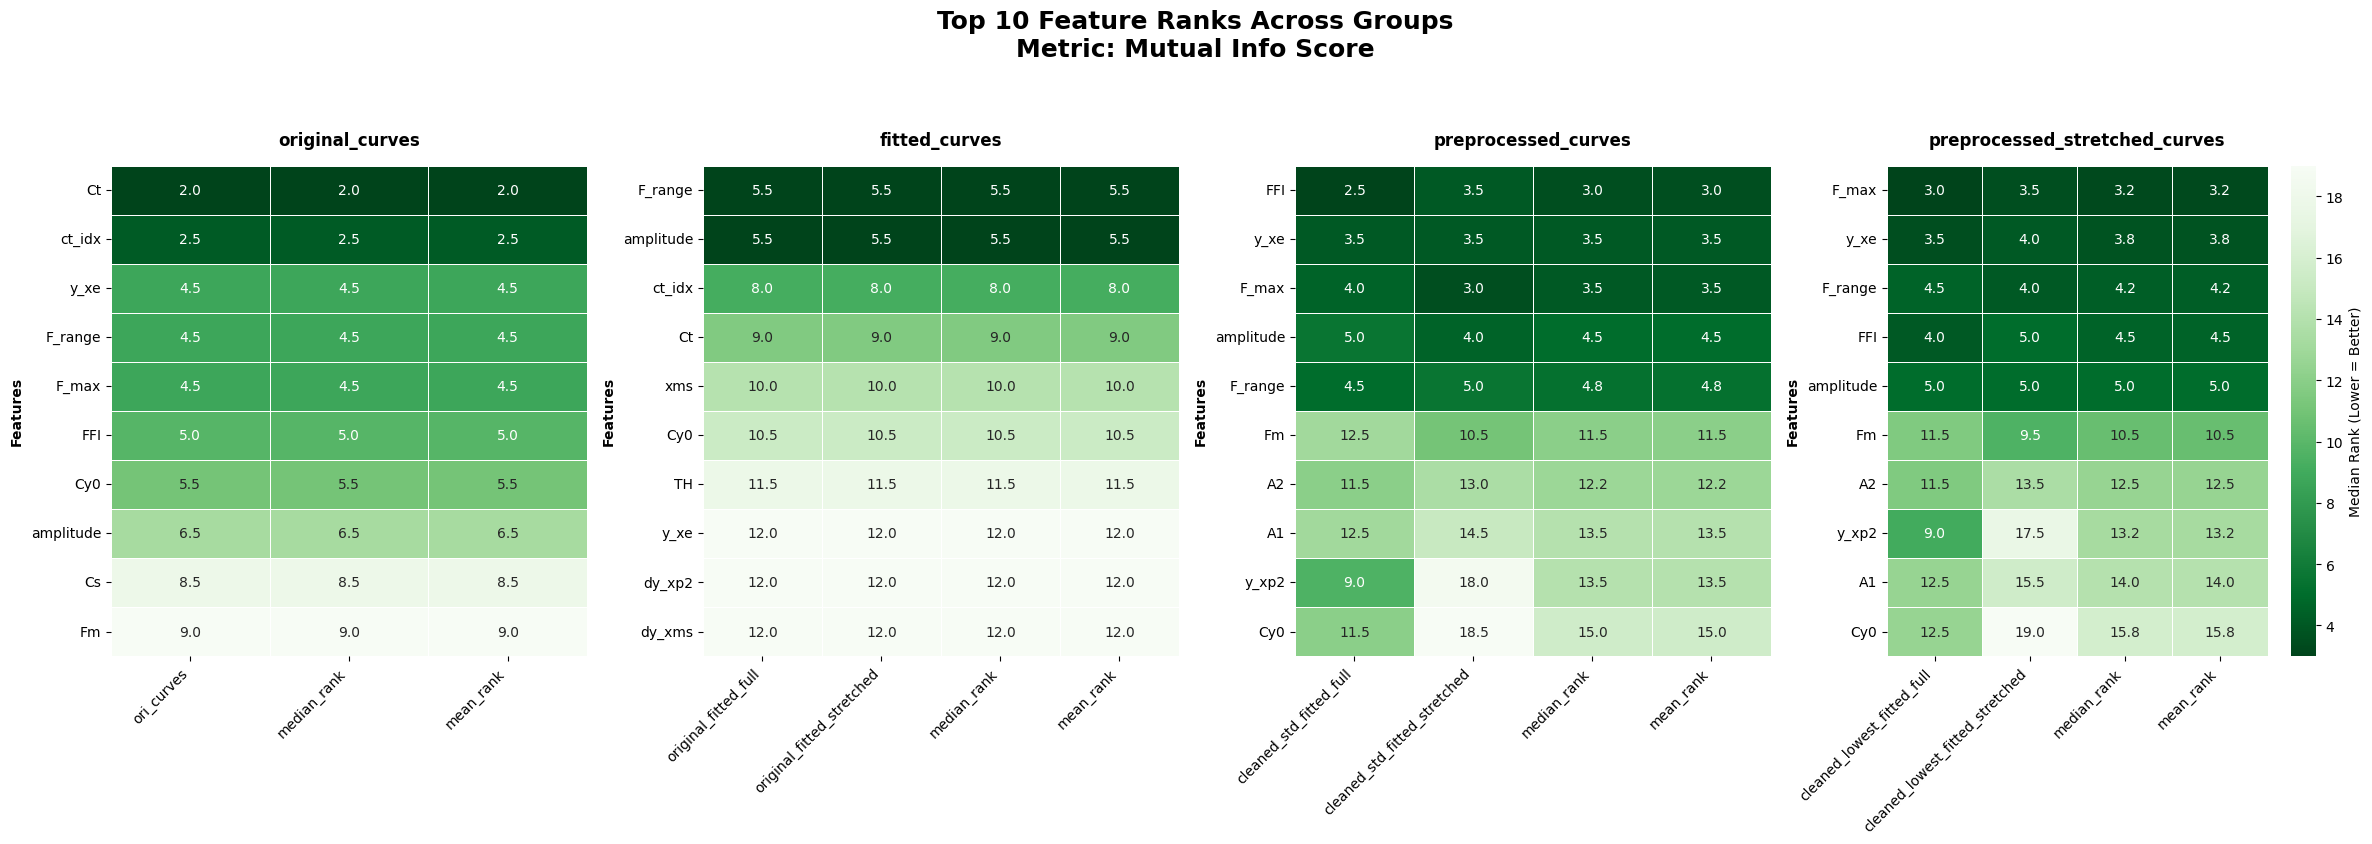

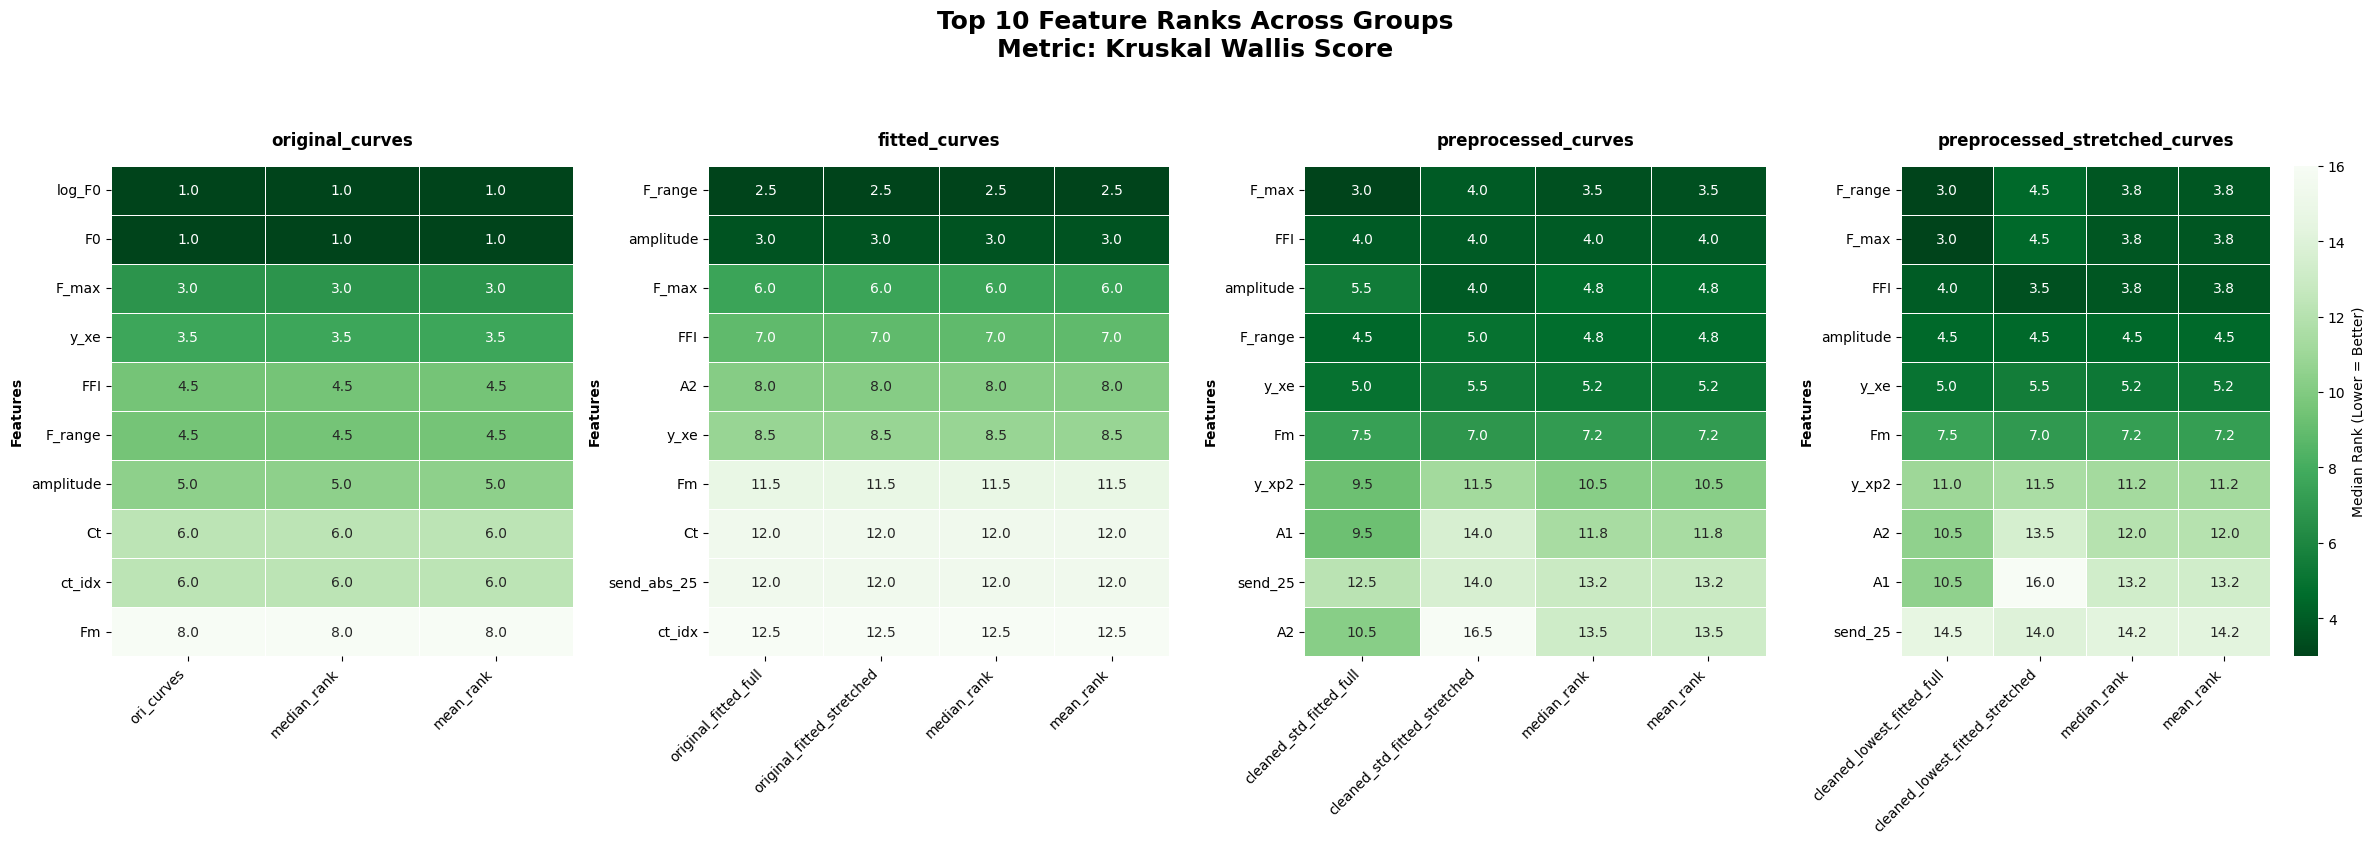

In [13]:
n_splits = len(curve_split)

for m in metrics:
    if m not in summary['curve_feature_median_rank']:
        print(f"Skipping {m} - not found in summary.")
        continue
        
    metric_df = summary['curve_feature_median_rank'][m]
    
    fig, axes = plt.subplots(nrows=1, ncols=n_splits, figsize=(6 * n_splits, 8))
    
    if n_splits == 1:
        axes = [axes]
        
    clean_metric_name = m.replace('_', ' ').title()
    fig.suptitle(f"Top 10 Feature Ranks Across Groups\nMetric: {clean_metric_name}", fontsize=18, fontweight='bold', y=1.05)
    
    for i, (k, v) in enumerate(curve_split.items()):
        split_columns = ['feature'] + v
        
        valid_cols = [c for c in split_columns if c in metric_df.columns]
        
        display_colorbar = (i == n_splits - 1)
        
        plot_feature_heatmap_on_ax(
            df=metric_df[valid_cols], 
            ax=axes[i], 
            title=f"{k}", 
            calculate_summary=True, 
            n_rank=10,
            show_cbar=display_colorbar
        )
        
    plt.tight_layout()
    plt.show()
    
    # Optional: Save the figure dynamically based on the metric name
    # save_path = f"feature_rank_heatmap_{m}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.close(fig)

## Top Features Viz

In [14]:
def plot_feature_visuals(ax_dist, ax_scat, feature, feature_values, y_target, title_text):
    """
    Plots the normalized KDE distribution and the sorted scatter plot for a given feature.
    Automatically handles NaNs and infinite values.
    """
    # Clean Data (NaN / Inf Handling)
    valid_mask = ~np.isnan(feature_values) & ~np.isinf(feature_values)
    val_x = feature_values[valid_mask]
    val_y = y_target[valid_mask]
    
    if len(val_x) == 0:
        ax_dist.set_title(f"{title_text}\n(NO VALID DATA)")
        ax_scat.set_title(f"{title_text}\n(NO VALID DATA)")
        return
        
    df_plot = pd.DataFrame({feature: val_x, 'Target': val_y})
    
    # ---------------------------------------------------------
    # PLOT A: Histogram + KDE Distribution
    # ---------------------------------------------------------
    try:
        # Attempt to plot with KDE
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=True, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        
        # Force the KDE line to be black
        for line in ax_dist.lines:
            line.set_color('black')
            line.set_linewidth(1.5)
            
    except Exception:
        # Fallback if KDE fails due to LinAlgError (Zero Variance / Singular Matrix)
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=False, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        # Add a small note that KDE failed for transparency
        ax_dist.text(0.95, 0.95, 'KDE Failed', transform=ax_dist.transAxes, 
                     color='red', fontsize=8, ha='right', va='top')
        
    ax_dist.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_dist.set_xlabel(feature, fontsize=9)
    ax_dist.set_ylabel("Density", fontsize=9)
    
    # ---------------------------------------------------------
    # PLOT B: Sorted Scatter Plot (Event Number)
    # ---------------------------------------------------------
    sort_indices = np.argsort(val_y)
    sorted_y = val_y[sort_indices]
    sorted_feature = val_x[sort_indices]
    x_events = np.arange(len(sorted_feature))
    
    df_scatter = pd.DataFrame({
        'Event Number': x_events,
        feature: sorted_feature,
        'Target': sorted_y
    })
    
    sns.scatterplot(
        data=df_scatter, x='Event Number', y=feature, hue='Target', 
        palette='colorblind', edgecolor=None, s=25, 
        ax=ax_scat, legend=False
    )

    ax_scat.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_scat.set_xlabel("Event Number", fontsize=9)
    ax_scat.set_ylabel(f"{feature} Intensity", fontsize=9)

In [15]:
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "ori_curves"

dataset_idx = dataset_metadata["name"].index(SELECTED_DATASET_NAME)
curve_idx = curve_metadata["name"].index(SELECTED_CURVE_TYPE)

# 1. Get raw features and pre-calculated scores for this dataset/curve
selected_kf = dataset["kinetic_features"][dataset_idx][curve_idx]
selected_scores = dataset["feature_scores"][dataset_idx][curve_idx]
selected_y_well = np.array(dataset_metadata["Y_well"][dataset_idx])

top_n_ = 10

metrics = [
    "rf_importance", 
    "anova_score", 
    "silhouette_score", 
    "mutual_info_score", 
    "kruskal_wallis_score"
]

In [19]:
selected_kf[['Ct', 'ct_idx', 'Cy0']]

,Ct,ct_idx,Cy0
0,604.326102,136,-10.507775
1,621.980386,140,63.356190
2,538.263937,119,131.219310
3,540.826666,120,75.490004
4,569.618898,127,21.768730
...,...,...,...
12893,932.978926,219,-1094.837109
12894,738.894578,170,-1549.906525
12895,513.170705,113,-2184.159559
12896,807.709401,187,-1443.892592


In [30]:
dataset_metadata["name"]

['D20250808_E00_C00_F4500KHz_U_Sample_7',
 'D20250811_E00_C00_F4500KHz_U_Sample_6',
 'D20250812_E00_C00_F4500KHz_U_Sample_2_Rep2',
 'D20250815_E00_C00_F4500KHz_U_Sample_11_rep2',
 'D20250818_E00_C00_F4500KHz_U_Sample_13',
 'D20250818_E00_C00_F4500KHz_U_Sample_15',
 'D20250818_E00_C00_F4500KHz_U_Sample_17',
 'D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3',
 'D20250826_E00_C00_F4500KHz_U_Sample_14_rep2',
 'D20250828_E00_C00_F4500KHz_U_Sample_mix_3']

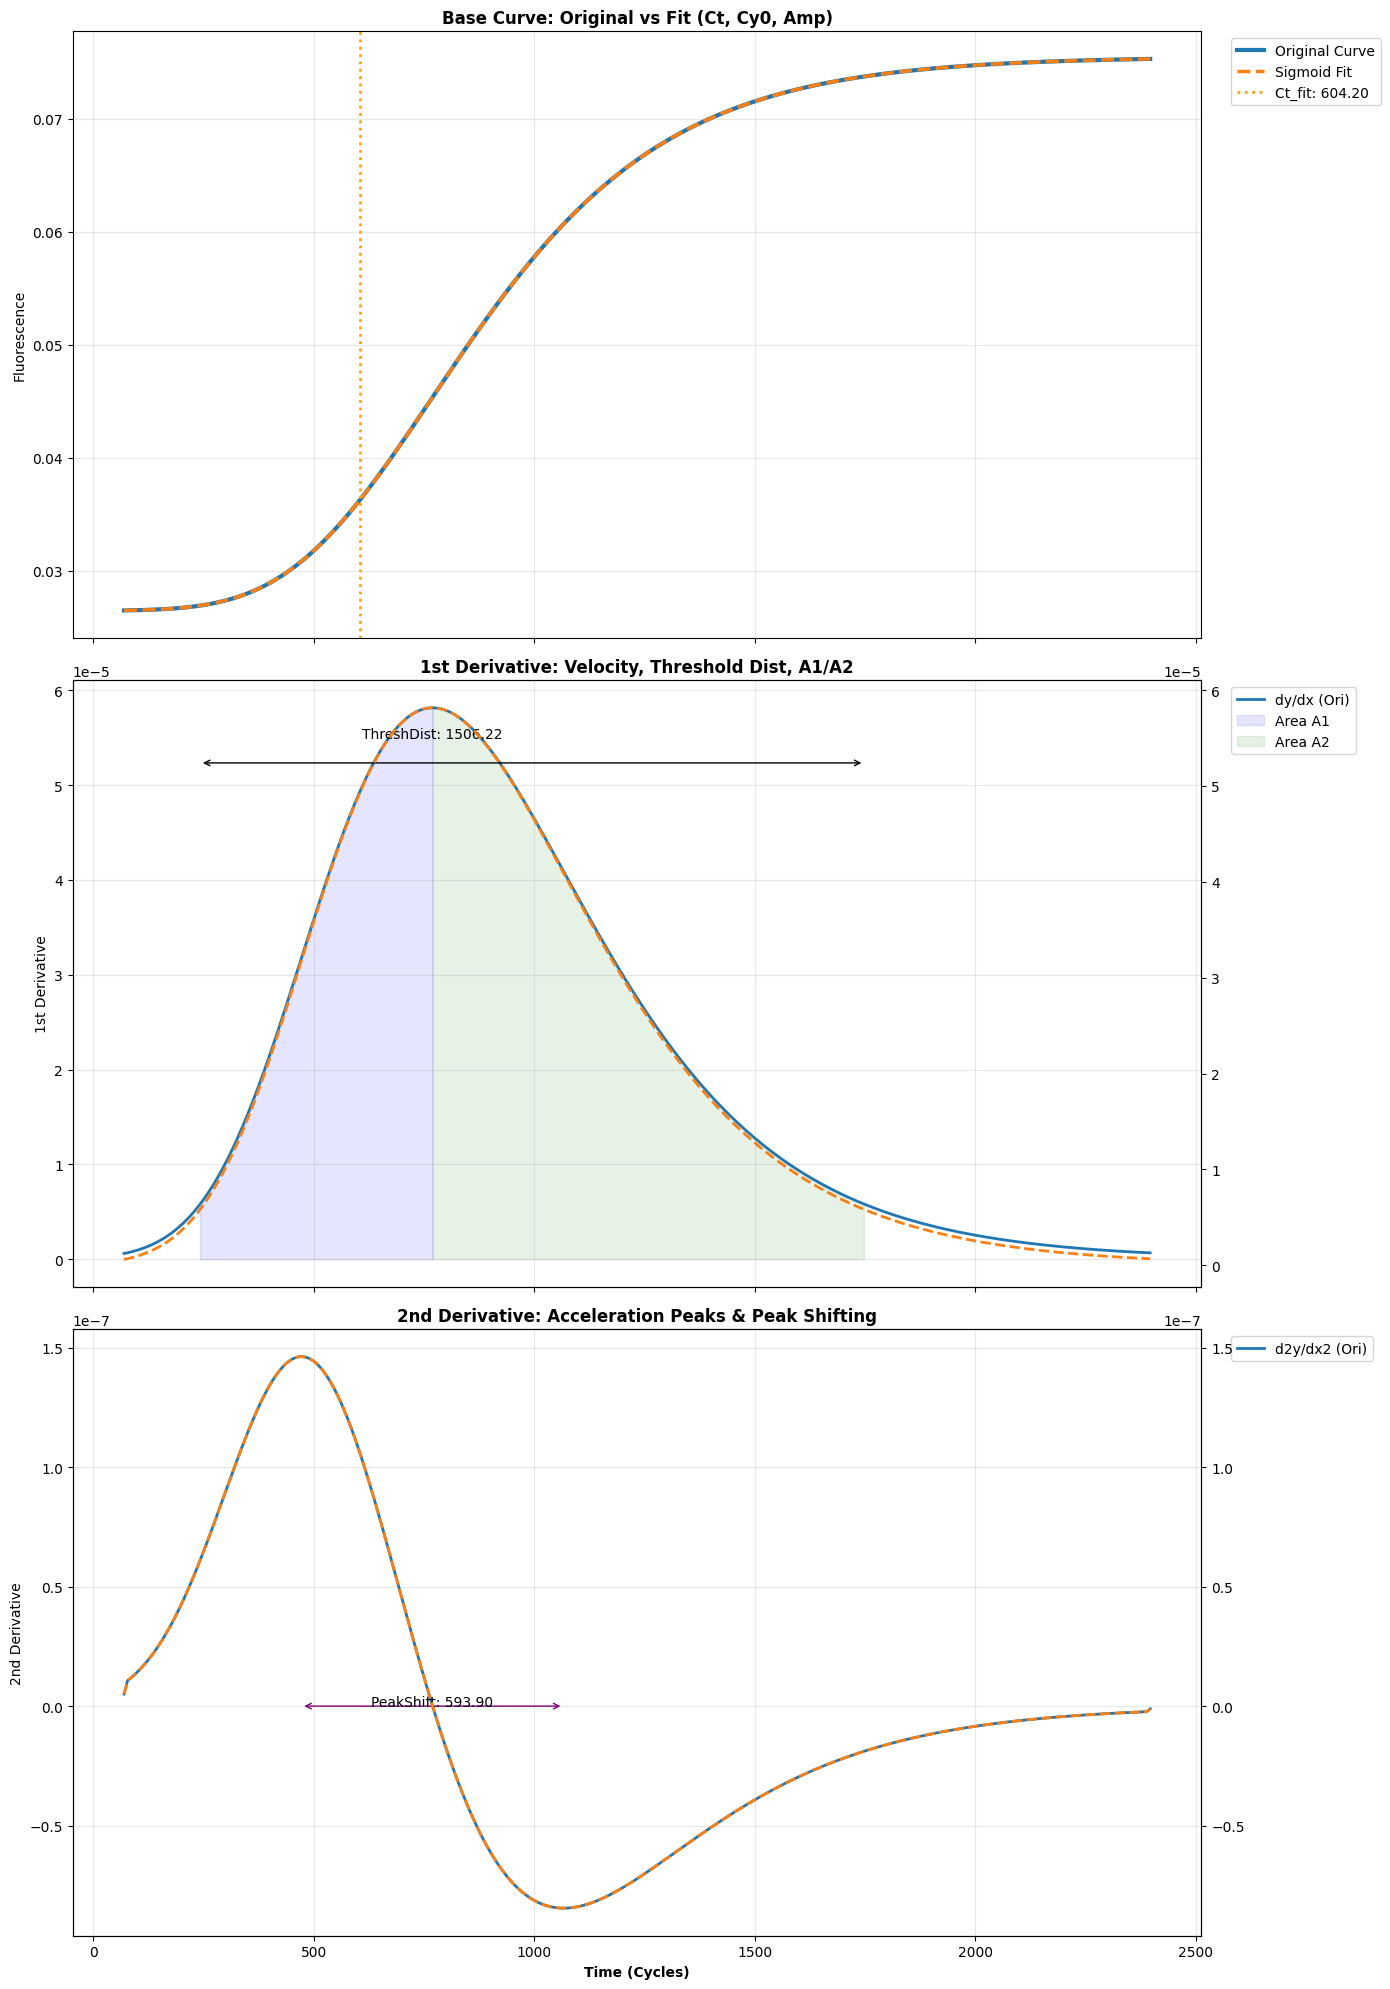

In [51]:
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "ori_curves"
SELECTED_CURVE_TYPE = "original_fitted_full"

# Lookups
dataset_idx = dataset_metadata["name"].index(SELECTED_DATASET_NAME)
curve_idx = curve_metadata["name"].index(SELECTED_CURVE_TYPE)
curve_idx_sigfit = curve_metadata["name"].index("original_fitted_full")
curve_sample_idx = 0

# Extract the Time (X), Curves (Y), and the Feature Row
x_time = dataset_metadata["timestamps"][dataset_idx]
y_ori = dataset["dataset_curves"][dataset_idx][curve_idx][curve_sample_idx]
y_fit = dataset["dataset_curves"][dataset_idx][curve_idx_sigfit][curve_sample_idx]

# IMPORTANT: Save features to a separate variable, don't overwrite curve_sample_idx!
sample_features = dataset["kinetic_features"][dataset_idx][curve_idx].iloc[curve_sample_idx]

# Calculate derivatives for plotting
dy_ori = np.gradient(y_ori, x_time)
dy_fit = np.gradient(y_fit, x_time)
d2y_ori = np.gradient(dy_ori, x_time)
d2y_fit = np.gradient(dy_fit, x_time)

# ==========================================
# PLOTTING
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Helper to find index of a timestamp
get_idx = lambda val: np.argmin(np.abs(x_time - val))

# Setup Figure: 3 rows (Base, 1st Deriv, 2nd Deriv)
fig, axes = plt.subplots(3, 1, figsize=(14, 20), sharex=True)
ax1, ax2, ax3 = axes

# 1. Base Curve: Plotting Original + Fit
ax1.plot(x_time, y_ori, label="Original Curve", lw=3, color='#1f77b4')
ax1.plot(x_time, y_fit, label="Sigmoid Fit", ls='--', lw=2.5, color='#ff7f0e')

# Annotate Ct, Cy0, TH, Amplitude
for feat, color, lbl in [('Ct_ori', 'blue', 'Ct_ori'), ('Ct', 'orange', 'Ct_fit')]:
    if pd.notna(sample_features.get(feat)):
        ax1.axvline(sample_features[feat], color=color, ls=':', lw=2, label=f'{lbl}: {sample_features[feat]:.2f}')

if pd.notna(sample_features.get('Cy0_ori')):
    ax1.plot([sample_features['Cy0_ori'], sample_features['xms']], [0, sample_features['y_xms']], 
             color='red', lw=2, label='Cy0_ori Tangent')
    ax1.scatter(sample_features['Cy0_ori'], 0, color='red', zorder=5)

ax1.set_title("Base Curve: Original vs Fit (Ct, Cy0, Amp)", fontweight='bold')
ax1.set_ylabel("Fluorescence")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# 2. 1st Derivative: Velocities, Areas (A1/A2), Threshold Dist
ax2.plot(x_time, dy_ori, label="dy/dx (Ori)", lw=2, color='#1f77b4')
ax2_fit = ax2.twinx()
ax2_fit.plot(x_time, dy_fit, label="dy/dx (Fit)", ls='--', lw=2, color='#ff7f0e')

# Shade Areas A1/A2
if pd.notna(sample_features.get('A1')):
    idx1, idx2 = get_idx(sample_features['xs']), get_idx(sample_features['xms'])
    ax2.fill_between(x_time[idx1:idx2+1], 0, dy_ori[idx1:idx2+1], color='blue', alpha=0.1, label='Area A1')
if pd.notna(sample_features.get('A2')):
    idx1, idx2 = get_idx(sample_features['xms']), get_idx(sample_features['xe'])
    ax2.fill_between(x_time[idx1:idx2+1], 0, dy_ori[idx1:idx2+1], color='green', alpha=0.1, label='Area A2')

# Draw Distance Metrics
y_h = np.nanmax(dy_ori) * 0.9
if pd.notna(sample_features.get('threshold_distance')):
    ax2.annotate('', xy=(sample_features['xs'], y_h), xytext=(sample_features['xe'], y_h), arrowprops=dict(arrowstyle='<->'))
    ax2.text(sample_features['xms'], y_h*1.05, f"ThreshDist: {sample_features['threshold_distance']:.2f}", ha='center')

ax2.set_title("1st Derivative: Velocity, Threshold Dist, A1/A2", fontweight='bold')
ax2.set_ylabel("1st Derivative")
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# 3. 2nd Derivative: Accel Peaks & Peak Shifting
ax3.plot(x_time, d2y_ori, label="d2y/dx2 (Ori)", lw=2, color='#1f77b4')
ax3_fit = ax3.twinx()
ax3_fit.plot(x_time, d2y_fit, label="d2y/dx2 (Fit)", ls='--', lw=2, color='#ff7f0e')

# Peak Shifting
if pd.notna(sample_features.get('peak_shifting_distance')):
    ax3.annotate('', xy=(sample_features['xp1'], 0), xytext=(sample_features['xp2'], 0), arrowprops=dict(arrowstyle='<->', color='purple'))
    ax3.text(np.mean([sample_features['xp1'], sample_features['xp2']]), 0, f"PeakShift: {sample_features['peak_shifting_distance']:.2f}", ha='center')

ax3.set_title("2nd Derivative: Acceleration Peaks & Peak Shifting", fontweight='bold')
ax3.set_xlabel("Time (Cycles)", fontweight='bold')
ax3.set_ylabel("2nd Derivative")
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [93]:
curve_metadata["name"]

['ori_curves',
 'ori_curves_avg',
 'original_fitted_full',
 'original_fitted_stretched',
 'cleaned_std_fitted_full',
 'cleaned_std_fitted_stretched',
 'cleaned_lowest_fitted_full',
 'cleaned_lowest_fitted_stretched']

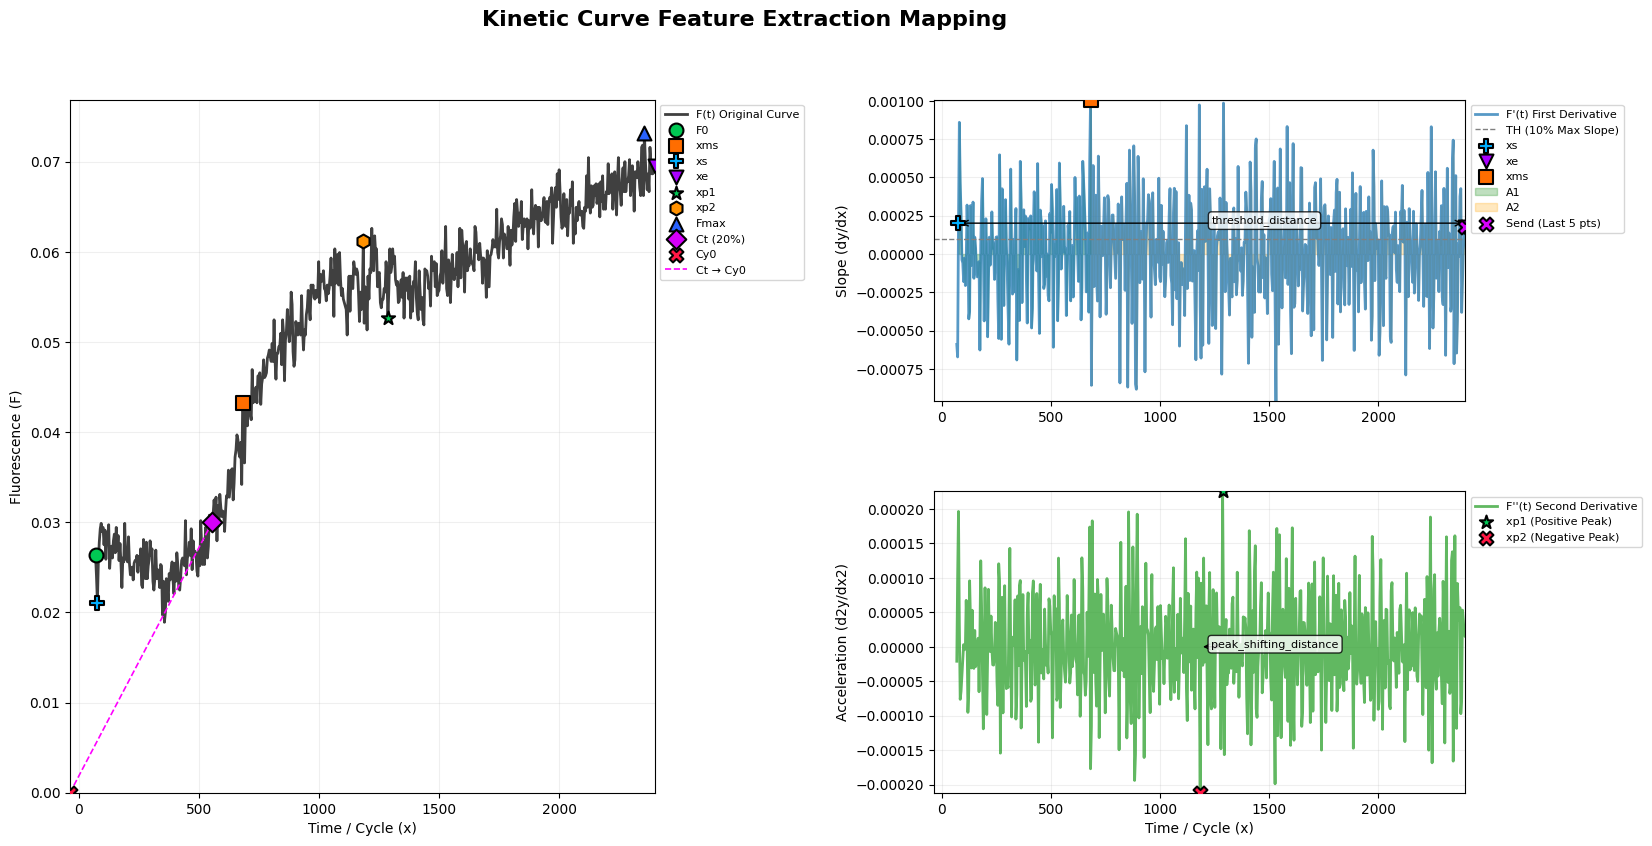

In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# DATA / FEATURES (as you already have)
# ----------------------------
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "ori_curves"

dataset_idx = dataset_metadata["name"].index(SELECTED_DATASET_NAME)
curve_idx = curve_metadata["name"].index(SELECTED_CURVE_TYPE)
curve_sample_idx = 120

x_time = dataset_metadata["timestamps"][dataset_idx]
y_ori = dataset["dataset_curves"][dataset_idx][curve_idx][curve_sample_idx]
sample_features = dataset["kinetic_features"][dataset_idx][curve_idx].iloc[curve_sample_idx]

dy_ori = np.gradient(y_ori, x_time)
d2y_ori = np.gradient(dy_ori, x_time)
get_idx = lambda val: np.argmin(np.abs(x_time - val))

# ----------------------------
# SAFE FEATURE HELPERS
# ----------------------------
def scalar_feat(val):
    if val is None:
        return np.nan
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(val).flatten()
        if arr.size == 0:
            return np.nan
        for v in arr:
            if np.isfinite(v):
                return float(v)
        return np.nan
    return float(val) if np.isfinite(val) else np.nan

def F(name, default=np.nan):
    return scalar_feat(sample_features.get(name, default))

xmin, xmax = min(F("Cy0"), F("Cy0_ori"),np.nanmin(x_time)), np.nanmax(x_time)
ymin, ymax = min(0, np.nanmin(y_ori)), np.nanmax(y_ori) * 1.05
dymin, dymax = np.nanmin(dy_ori), np.nanmax(dy_ori)
d2ymin, d2ymax = np.nanmin(d2y_ori), np.nanmax(d2y_ori)

# ----------------------------
# STYLE (distinct colors/markers)
# ----------------------------
SCATTER_SIZE = 100
EDGE = "black"
LW = 1.5
SCATTER_ALPHA = 1.0
Z = 10

BASE_STYLE = {
    "F0":        dict(color="#00C853", marker="o"),
    "Fmax":      dict(color="#2962FF", marker="^"),
    "Ct":        dict(color="#D500F9", marker="D"),
    "Cy0":       dict(color="#FF1744", marker="X"),
    "xms":       dict(color="#FF6D00", marker="s"),
    "xs":        dict(color="#00B0FF", marker="P"),
    "xe":        dict(color="#AA00FF", marker="v"),
    "xp1":       dict(color="#00C853", marker="*"),
    "xp2":       dict(color="#FF9100", marker="h"),
}

D1_STYLE = {
    "xs":   dict(color="#00B0FF", marker="P"),
    "xe":   dict(color="#AA00FF", marker="v"),
    "xms":  dict(color="#FF6D00", marker="s"),
    "Send": dict(color="#D500F9", marker="X"),
}

D2_STYLE = {
    "xp1": dict(color="#00C853", marker="*"),
    "xp2": dict(color="#FF1744", marker="X"),
}

# ----------------------------
# LAYOUT
# ----------------------------
fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1],
                      wspace=0.5, hspace=0.3)

ax_base = fig.add_subplot(gs[:, 0])
ax_d1 = fig.add_subplot(gs[0, 1])
ax_d2 = fig.add_subplot(gs[1, 1])

fig.suptitle("Kinetic Curve Feature Extraction Mapping", fontsize=16, fontweight="bold")

# ======================================================
# LEFT: BASE CURVE
# ======================================================
ax_base.plot(x_time, y_ori, color="black", lw=2, label="F(t) Original Curve", alpha=0.75)
ax_base.set_xlabel("Time / Cycle (x)")
ax_base.set_ylabel("Fluorescence (F)")
ax_base.set_xlim(xmin, xmax)
ax_base.set_ylim(ymin, ymax)
ax_base.grid(True, alpha=0.2)

# Points/lines with legend only
if np.isfinite(F("F0")):
    ax_base.scatter(x_time[0], y_ori[0], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="F0", **BASE_STYLE["F0"])

if np.isfinite(F("xms")) and xmin <= F("xms") <= xmax:
    ax_base.scatter(F("xms"), y_ori[get_idx(F("xms"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="xms", **BASE_STYLE["xms"])

if np.isfinite(F("xs")) and xmin <= F("xs") <= xmax:
    ax_base.scatter(F("xs"), y_ori[get_idx(F("xs"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="xs", **BASE_STYLE["xs"])

if np.isfinite(F("xe")) and xmin <= F("xe") <= xmax:
    ax_base.scatter(F("xe"), y_ori[get_idx(F("xe"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="xe", **BASE_STYLE["xe"])

if np.isfinite(F("xp1")) and xmin <= F("xp1") <= xmax:
    ax_base.scatter(F("xp1"), y_ori[get_idx(F("xp1"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="xp1", **BASE_STYLE["xp1"])

if np.isfinite(F("xp2")) and xmin <= F("xp2") <= xmax:
    ax_base.scatter(F("xp2"), y_ori[get_idx(F("xp2"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="xp2", **BASE_STYLE["xp2"])

if np.isfinite(F("F_max_ori")):
    ax_base.scatter(x_time[np.argmax(y_ori)], np.max(y_ori), s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="Fmax_ori", **BASE_STYLE["Fmax"])

if np.isfinite(F("Ct_ori")) and xmin <= F("Ct_ori") <= xmax:
    ax_base.scatter(F("Ct_ori"), y_ori[get_idx(F("Ct_ori"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="Ct_ori (20%)", **BASE_STYLE["Ct"])

if np.isfinite(F("Cy0_ori")) and xmin <= F("Cy0_ori") <= xmax:
    ax_base.scatter(F("Cy0_ori"), 0, s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="Cy0_ori", **BASE_STYLE["Cy0"])

if np.isfinite(F("Ct_ori")) and np.isfinite(F("Cy0_ori")):
    ax_base.plot([F("Ct_ori"), F("Cy0_ori")],
                 [y_ori[get_idx(F("Ct_ori"))], 0],
                 ls="--", lw=1.2, color="magenta", label="Ct_ori → Cy0_ori")

# === Fitted ===
if np.isfinite(F("F_max")):
    ax_base.scatter(x_time[np.argmax(y_ori)], np.max(y_ori), s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="Fmax", **BASE_STYLE["Fmax"])

if np.isfinite(F("Ct")) and xmin <= F("Ct") <= xmax:
    ax_base.scatter(F("Ct"), y_ori[get_idx(F("Ct"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="Ct (20%)", **BASE_STYLE["Ct"])

if np.isfinite(F("Cy0")) and xmin <= F("Cy0") <= xmax:
    ax_base.scatter(F("Cy0"), 0, s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                    alpha=SCATTER_ALPHA, zorder=Z, label="Cy0", **BASE_STYLE["Cy0"])

if np.isfinite(F("Ct")) and np.isfinite(F("Cy0")):
    ax_base.plot([F("Ct"), F("Cy0")],
                 [y_ori[get_idx(F("Ct"))], 0],
                 ls="--", lw=1.2, color="magenta", label="Ct → Cy0")
    
ax_base.legend(bbox_to_anchor=(1, 1), fontsize=8)

# ======================================================
# TOP RIGHT: 1st DERIVATIVE
# ======================================================
ax_d1.plot(x_time, dy_ori, color="#1f77b4", lw=2, label="F'(t) First Derivative", alpha=0.75)
ax_d1.set_ylabel("Slope (dy/dx)")
ax_d1.set_xlim(xmin, xmax)
ax_d1.set_ylim(dymin, dymax)
ax_d1.grid(True, alpha=0.2)

if np.isfinite(F("TH")):
    ax_d1.axhline(F("TH"), color="gray", ls="--", lw=1, label="TH (10% Max Slope)")

if np.isfinite(F("xs")):
    ax_d1.scatter(F("xs"), dy_ori[get_idx(F("xs"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                  alpha=SCATTER_ALPHA, zorder=Z, label="xs", **D1_STYLE["xs"])
if np.isfinite(F("xe")):
    ax_d1.scatter(F("xe"), dy_ori[get_idx(F("xe"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                  alpha=SCATTER_ALPHA, zorder=Z, label="xe", **D1_STYLE["xe"])
if np.isfinite(F("xms")):
    ax_d1.scatter(F("xms"), dy_ori[get_idx(F("xms"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                  alpha=SCATTER_ALPHA, zorder=Z, label="xms", **D1_STYLE["xms"])

if np.isfinite(F("A1")) and np.isfinite(F("xs")) and np.isfinite(F("xms")):
    i1, i2 = get_idx(F("xs")), get_idx(F("xms"))
    ax_d1.fill_between(x_time[i1:i2+1], 0, dy_ori[i1:i2+1], color="green", alpha=0.25, label="A1")

if np.isfinite(F("A2")) and np.isfinite(F("xms")) and np.isfinite(F("xe")):
    i1, i2 = get_idx(F("xms")), get_idx(F("xe"))
    ax_d1.fill_between(x_time[i1:i2+1], 0, dy_ori[i1:i2+1], color="orange", alpha=0.25, label="A2")

if np.isfinite(F("threshold_distance")) and np.isfinite(F("xs")) and np.isfinite(F("xe")):
    y_h = np.nanmax(dy_ori) * 0.2
    ax_d1.annotate("", xy=(F("xs"), y_h), xytext=(F("xe"), y_h),
                   arrowprops=dict(arrowstyle="<->", color="black"))
    ax_d1.text((F("xs")+F("xe"))/2, y_h, "threshold_distance", fontsize=8,
               bbox=dict(boxstyle="round", fc="white", alpha=0.8))

if np.isfinite(F("Send")):
    ax_d1.scatter(x_time[-1], dy_ori[-1], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                  alpha=SCATTER_ALPHA, zorder=Z, label="Send (Last 5 pts)", **D1_STYLE["Send"])

ax_d1.legend(bbox_to_anchor=(1, 1), fontsize=8)

# ======================================================
# BOTTOM RIGHT: 2nd DERIVATIVE
# ======================================================
ax_d2.plot(x_time, d2y_ori, color="#2ca02c", lw=2, label="F''(t) Second Derivative", alpha=0.75)
ax_d2.set_xlabel("Time / Cycle (x)")
ax_d2.set_ylabel("Acceleration (d2y/dx2)")
ax_d2.set_xlim(xmin, xmax)
ax_d2.set_ylim(d2ymin, d2ymax)
ax_d2.grid(True, alpha=0.2)

if np.isfinite(F("xp1")):
    ax_d2.scatter(F("xp1"), d2y_ori[get_idx(F("xp1"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                  alpha=SCATTER_ALPHA, zorder=Z, label="xp1 (Positive Peak)", **D2_STYLE["xp1"])
if np.isfinite(F("xp2")):
    ax_d2.scatter(F("xp2"), d2y_ori[get_idx(F("xp2"))], s=SCATTER_SIZE, edgecolor=EDGE, linewidth=LW,
                  alpha=SCATTER_ALPHA, zorder=Z, label="xp2 (Negative Peak)", **D2_STYLE["xp2"])

if np.isfinite(F("peak_shifting_distance")) and np.isfinite(F("xp1")) and np.isfinite(F("xp2")):
    ax_d2.annotate("", xy=(F("xp1"), 0), xytext=(F("xp2"), 0),
                   arrowprops=dict(arrowstyle="<->", color="black"))
    ax_d2.text((F("xp1")+F("xp2"))/2, 0, "peak_shifting_distance", fontsize=8,
               bbox=dict(boxstyle="round", fc="white", alpha=0.8))

ax_d2.legend(bbox_to_anchor=(1, 1), fontsize=8)

plt.show()


In [113]:
print([F("Ct"), F("Cy0")])
print([y_ori[get_idx(F("Ct"))], 0])

[604.3261018932252, -10.507775324031968]
[0.0320110696911903, 0]


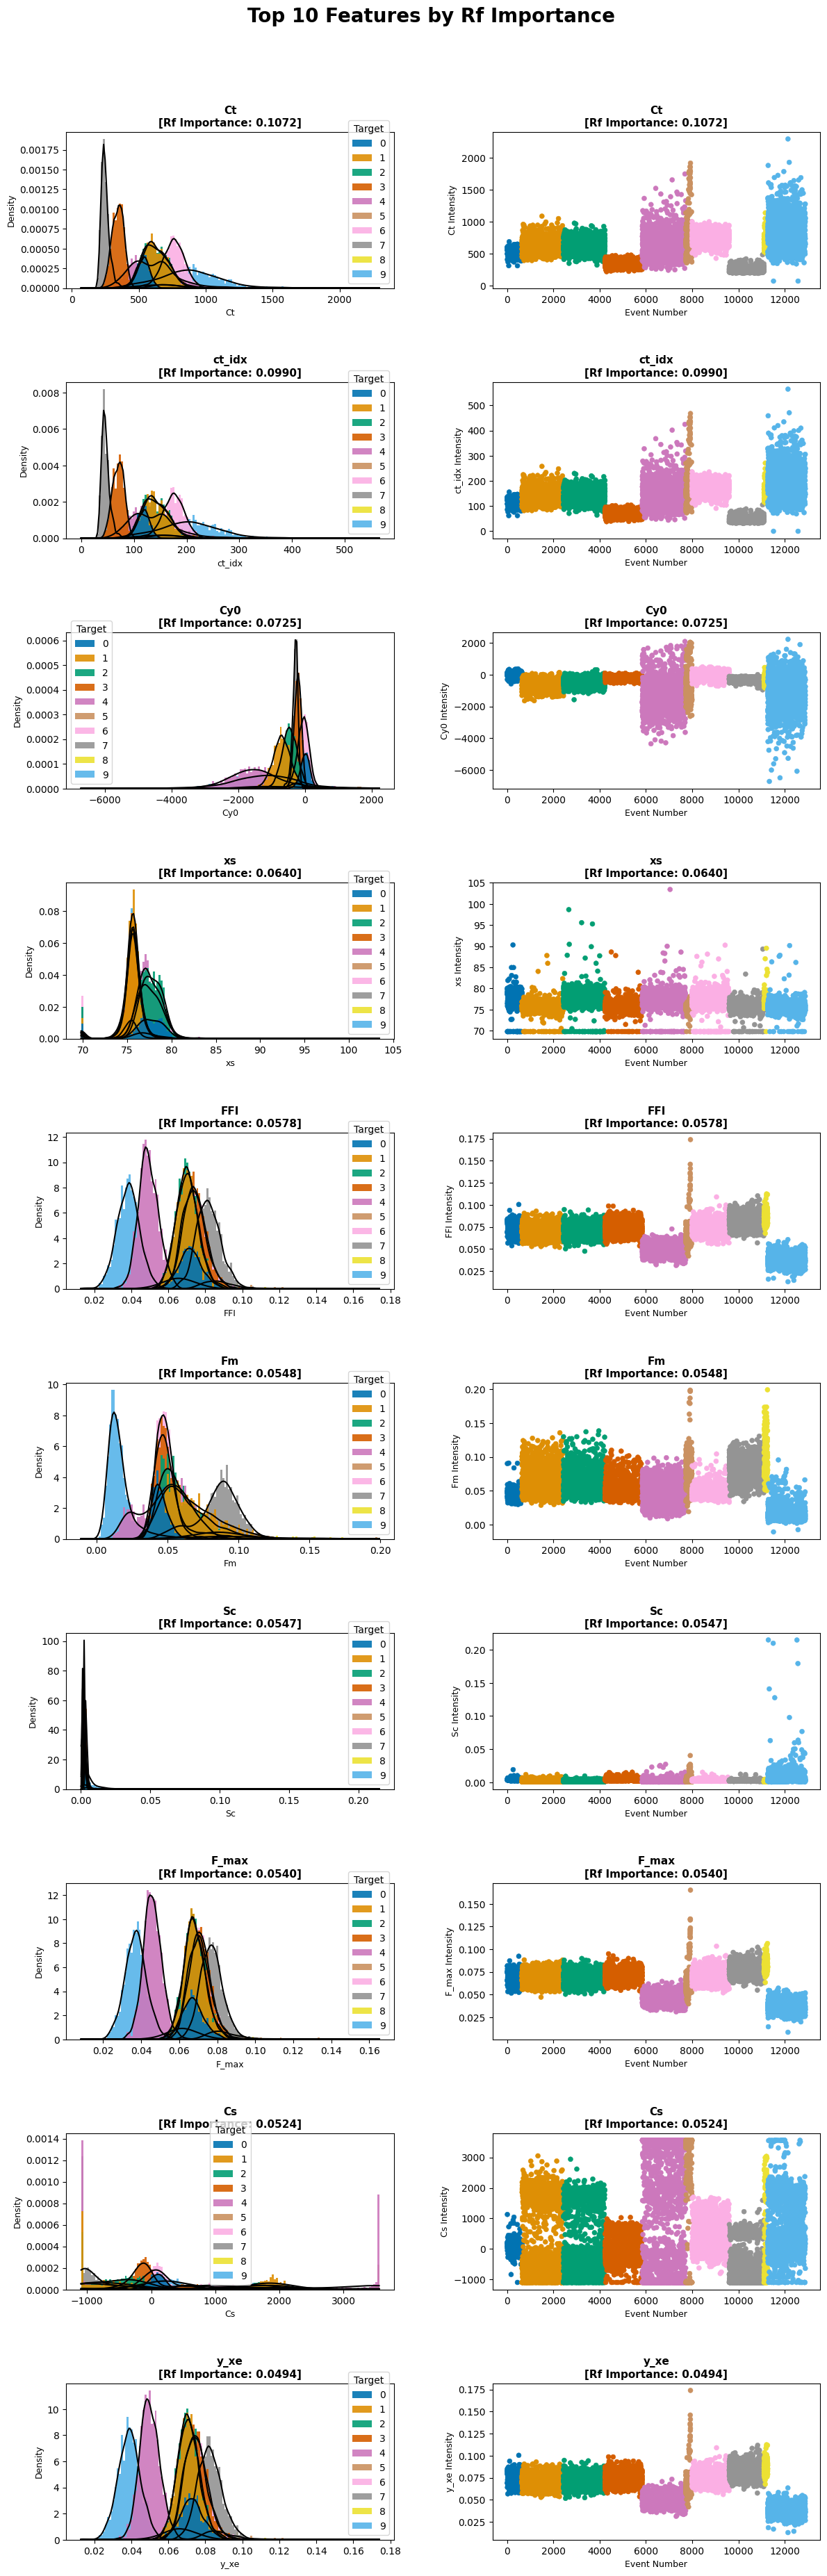

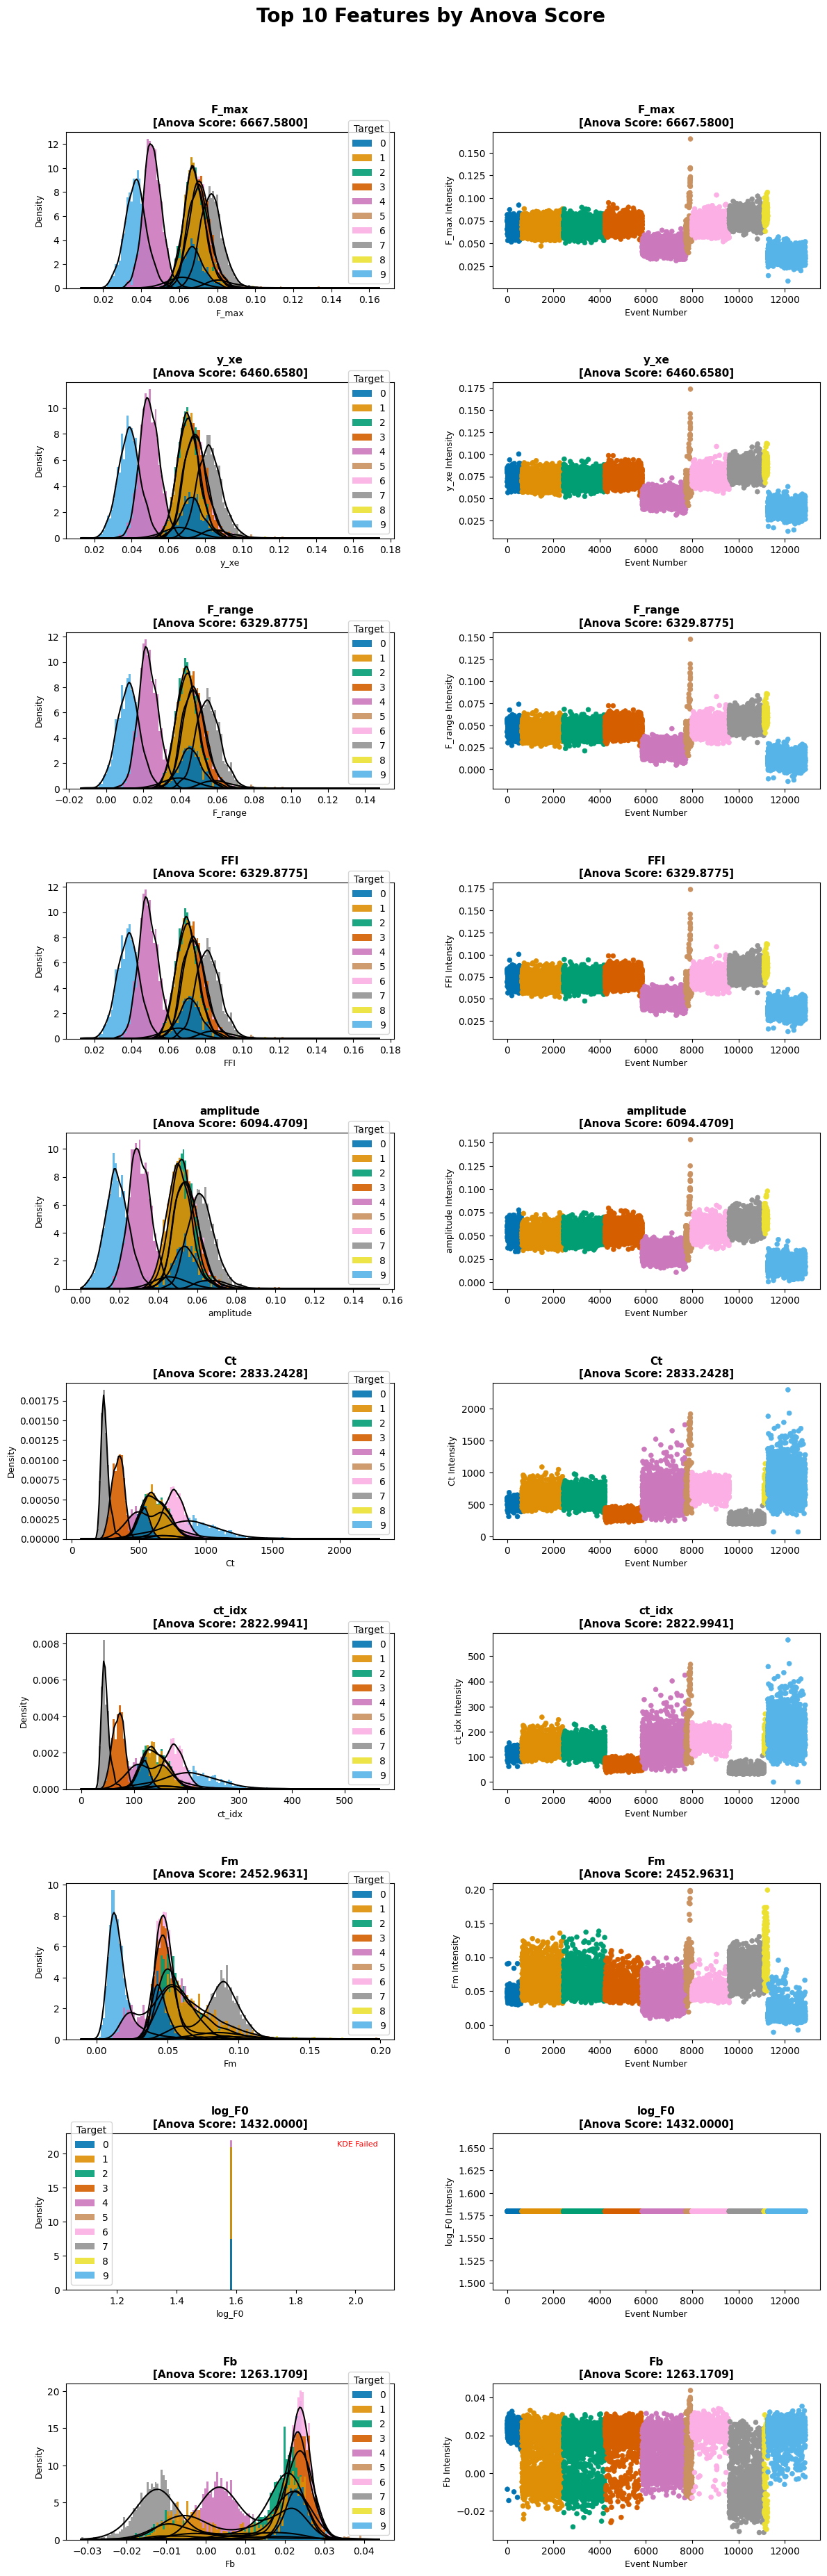

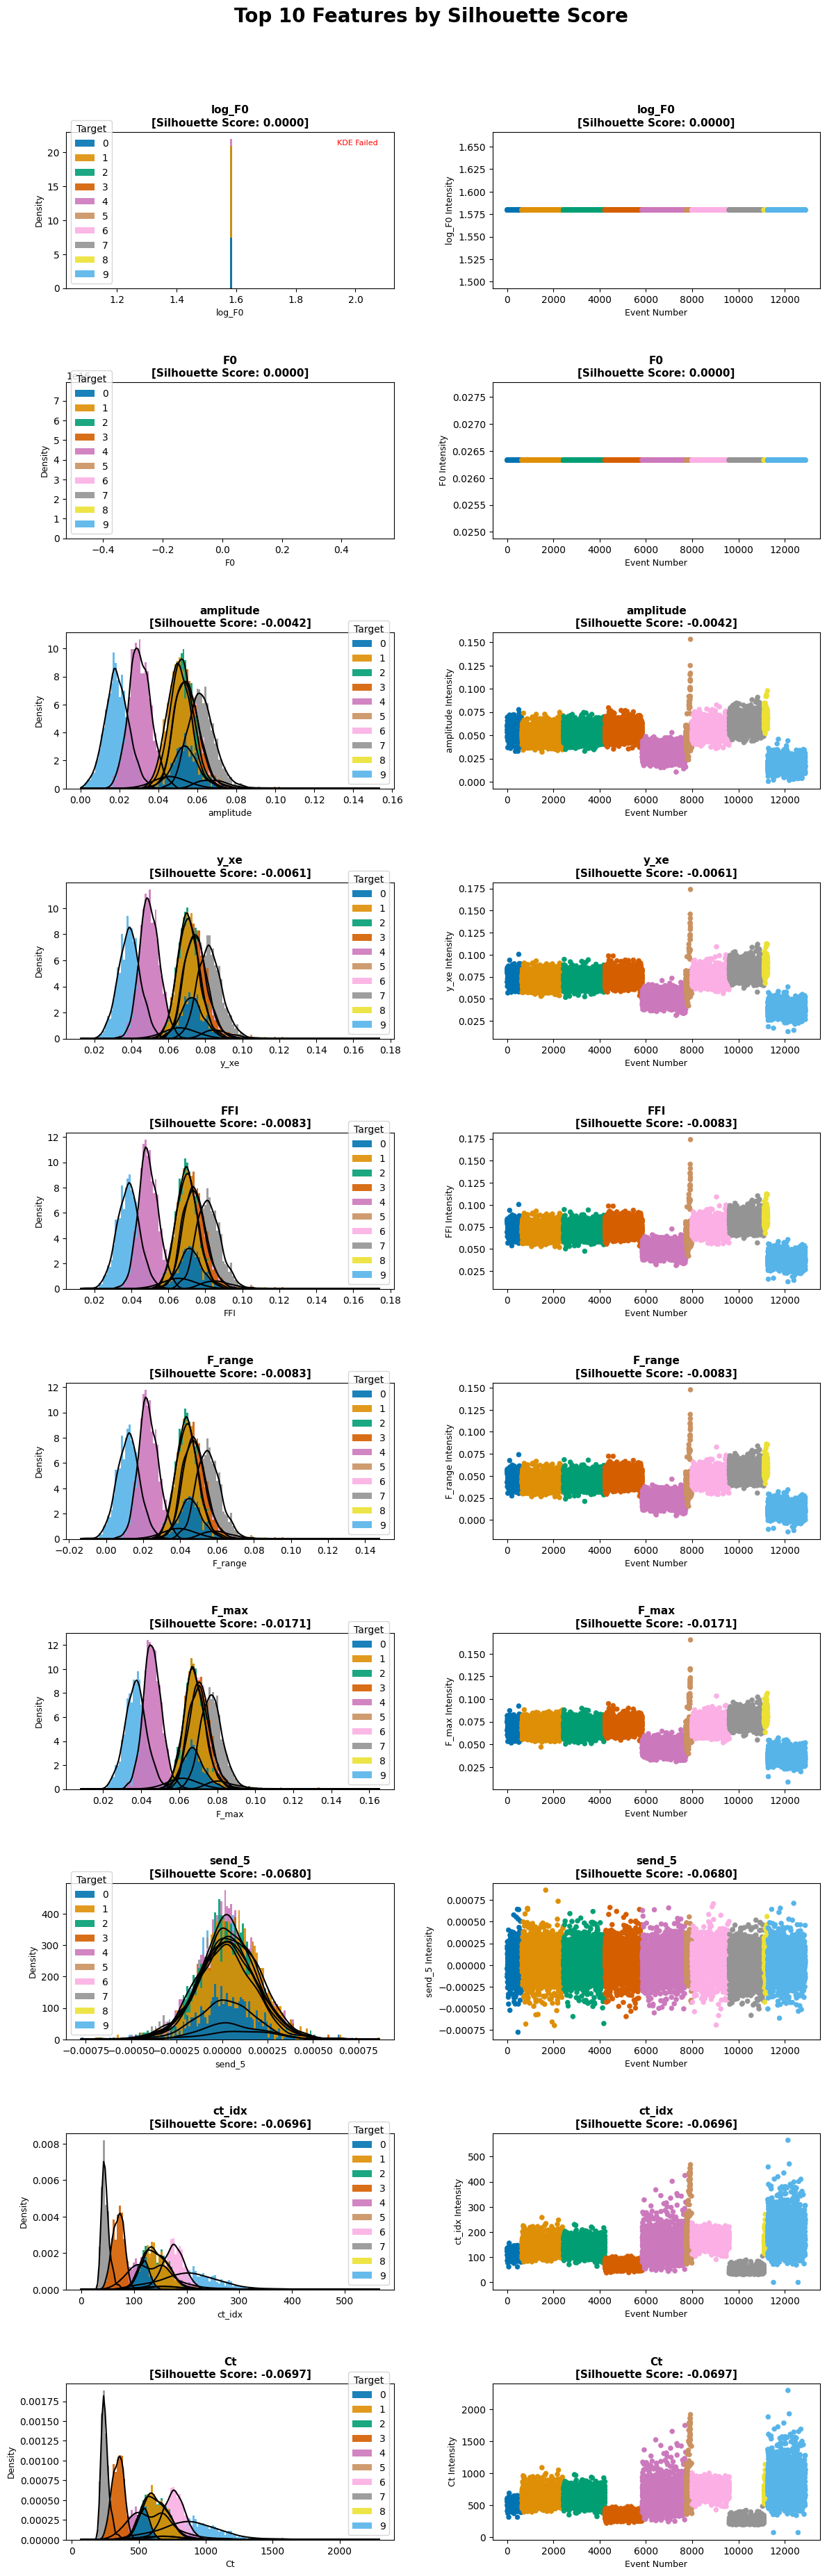

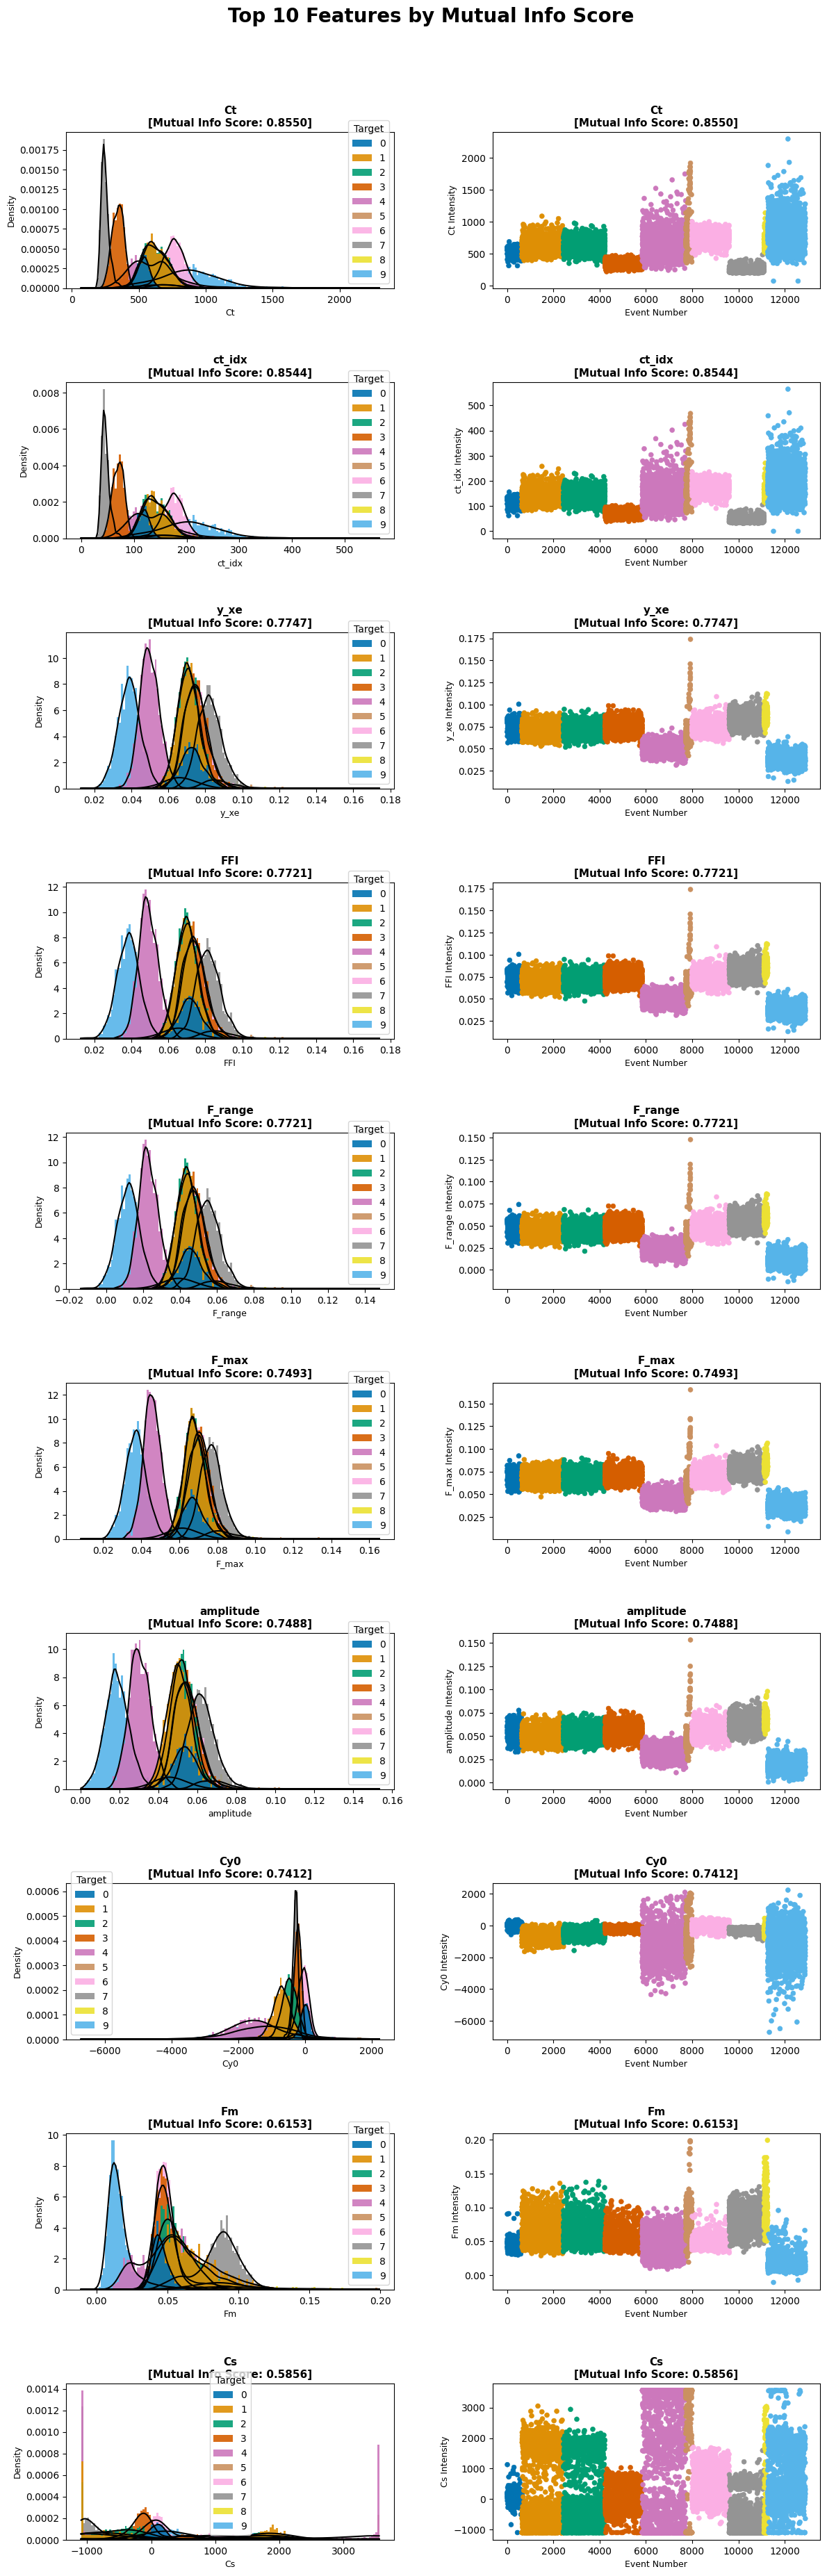

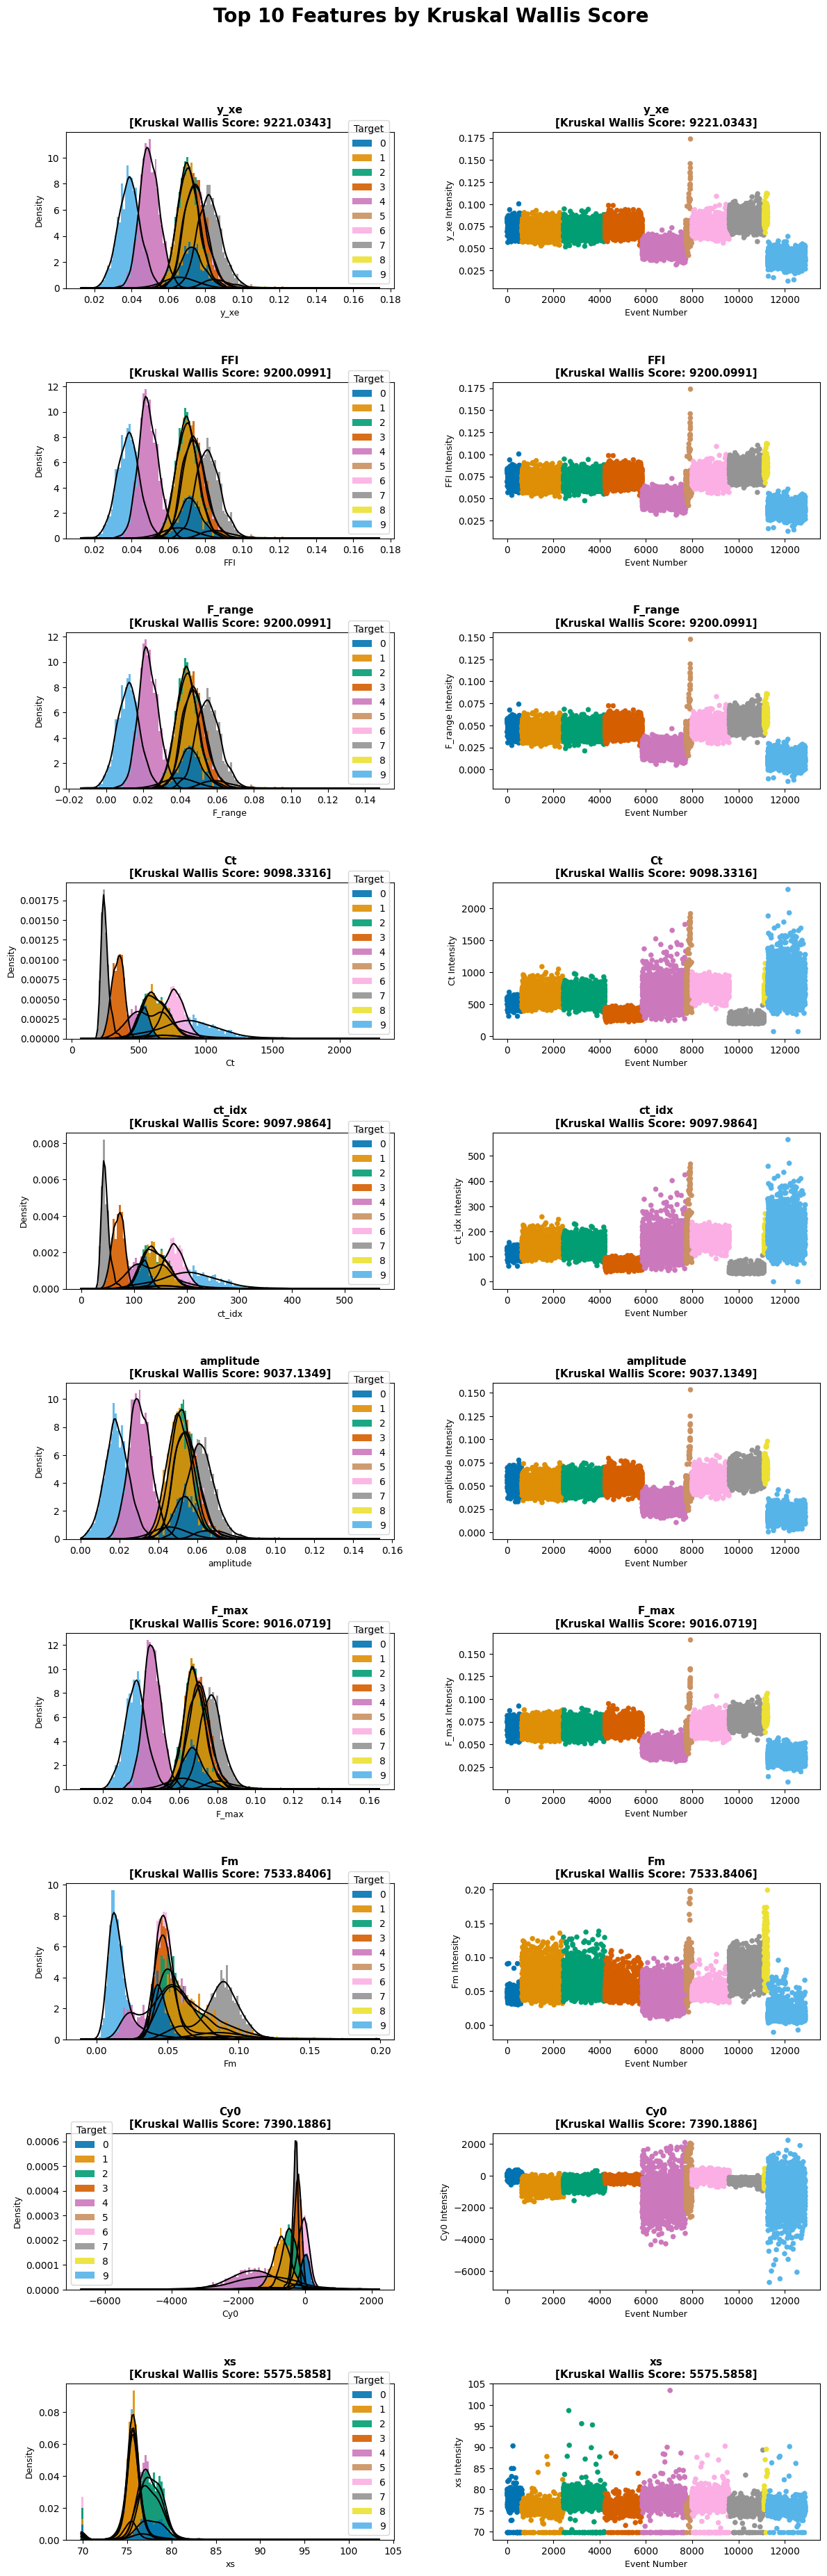

277

In [16]:
for m in metrics:
    sorted_scores = selected_scores.sort_values(by=m, ascending=False)
    
    valid_scores = sorted_scores[
        sorted_scores['feature'].isin(selected_kf.columns) & 
        ~sorted_scores['feature'].isin(EXCLUDED_FEATURES) &
        ~sorted_scores['feature'].str.contains('label') &
        ~sorted_scores['feature'].str.startswith('knn_top_')
    ].reset_index(drop=True)
    
    top_n_df = valid_scores.head(top_n_)
    
    fig, axes = plt.subplots(top_n_, 2, figsize=(14, top_n_ * 4.5))
    plt.subplots_adjust(hspace=0.6, wspace=0.3) 
    
    clean_metric_name = m.replace('_', ' ').title()
    
    for i in range(len(top_n_df)):
        feat = top_n_df.loc[i, 'feature']
        score_val = top_n_df.loc[i, m]
        feat_vals = selected_kf[feat].values
        
        title = f"{feat}\n[{clean_metric_name}: {score_val:.4f}]"
        
        ax_dist = axes[i, 0] if top_n_ > 1 else axes[0]
        ax_scat = axes[i, 1] if top_n_ > 1 else axes[1]
        
        plot_feature_visuals(ax_dist, ax_scat, feat, feat_vals, selected_y_well, title)
    
    fig.suptitle(f'Top {top_n_} Features by {clean_metric_name}', fontsize=20, fontweight='bold', y=0.92)

    plt.show()
    plt.close(fig)

gc.collect()